<a href="https://colab.research.google.com/github/gabriel2lucky1990/adult-obesity-risk-modelling-england/blob/main/Predicting_Obesity_From_Health_Behaviors_in_England.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adult Obesity Prediction in England
## Using Behavioral and Socioeconomic Health Indicators

**Data Source:** NHS Fingertips (2020-2023)  
**Geographic Level:** English Local Authorities  
**Student:** Gabriel Lucky Lotanna  
**Supervisor:** Dhairya Kataria
**Institution:** University of Hertfordshire  

---

## Project Overview

**Research Questions:**
1. Which behavioral health indicators and socioeconomic determinants are most strongly associated with adult obesity prevalence across English Local Authorities?
2. Which supervised machine learning models provide optimal predictive performance for modeling area-level obesity?
3. Do model explainability techniques reveal the relative contributions of behavioral versus socioeconomic determinants?

**Features:**
- **Behavioral (3):** Physical inactivity, smoking prevalence, diet (5-a-day)
- **Socioeconomic (2):** Index of Multiple Deprivation (IMD), children in low income

**Target:** Adult obesity prevalence (%)

---

**✓ COMPREHENSIVE VISUALIZATIONS INCLUDED:**
- Distribution histograms for all variables
- Pairwise relationship plots
- Correlation heatmap
- **Actual vs Predicted plots for EACH model**
- **Residual analysis plots for EACH model**
- **Residual distribution plots for EACH model**
- **Feature coefficients/importance for EACH model**
- Comprehensive model comparison visualizations

---
# Part 1: Setup and Data Loading

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")
print("Matplotlib backend:", plt.get_backend())

Libraries imported successfully!
Matplotlib backend: module://matplotlib_inline.backend_inline


In [2]:
# Mount Google Drive (for Google Colab)
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted successfully!")

Mounted at /content/drive
Google Drive mounted successfully!


In [3]:
# Load enhanced dataset
# This dataset contains both behavioral and socioeconomic features

print("ADULT OBESITY PREDICTION - ENGLAND LOCAL AUTHORITIES")

# Load data from Google Drive
df = pd.read_csv('/content/drive/MyDrive/obesity_enhanced_5features.csv')

print(f"\nDataset loaded: {len(df)} observations")
print(f"Time period: 2020-2023")
print(f"Geographic units: English Local Authorities")
print(f"\nShape: {df.shape}")
print(f"Columns: {list(df.columns)}")

ADULT OBESITY PREDICTION - ENGLAND LOCAL AUTHORITIES

Dataset loaded: 583 observations
Time period: 2020-2023
Geographic units: English Local Authorities

Shape: (583, 9)
Columns: ['Area Code', 'Area Name', 'year', 'obesity_prevalence', 'physical_inactivity', 'smoking_prevalence', 'diet_5_a_day_pct', 'imd_score', 'children_low_income_pct']


In [4]:
# Descriptive Statistics

print("DESCRIPTIVE STATISTICS")

# Select numeric columns for analysis
numeric_cols = ['obesity_prevalence', 'physical_inactivity', 'smoking_prevalence',
                'diet_5_a_day_pct', 'imd_score', 'children_low_income_pct']

# Display summary statistics
print("\nSummary Statistics:")
print(df[numeric_cols].describe().round(2))

# Check for missing values
print("\nMissing Values:")
print(df[numeric_cols].isnull().sum())

# Year distribution
print("\nYears in dataset:")
print(df['year'].value_counts().sort_index())

print(f"\nNumber of unique Local Authorities: {df['Area Code'].nunique()}")

DESCRIPTIVE STATISTICS

Summary Statistics:
       obesity_prevalence  physical_inactivity  smoking_prevalence  diet_5_a_day_pct  imd_score  children_low_income_pct
count              583.00               583.00              583.00            583.00     583.00                   583.00
mean                26.53                23.56               11.99             31.19      23.12                    18.11
std                  5.84                 5.00                2.92              5.62       8.09                     5.91
min                 10.24                10.81                4.10             18.84       5.85                     5.63
25%                 22.83                20.02               10.10             27.18      16.79                    13.16
50%                 26.66                22.85               12.00             30.91      22.96                    18.16
75%                 30.48                27.19               13.70             35.44      28.10              


# Part 2: Exploratory Data Analysis (EDA)

EXPLORATORY DATA ANALYSIS

1. Creating distribution histograms...


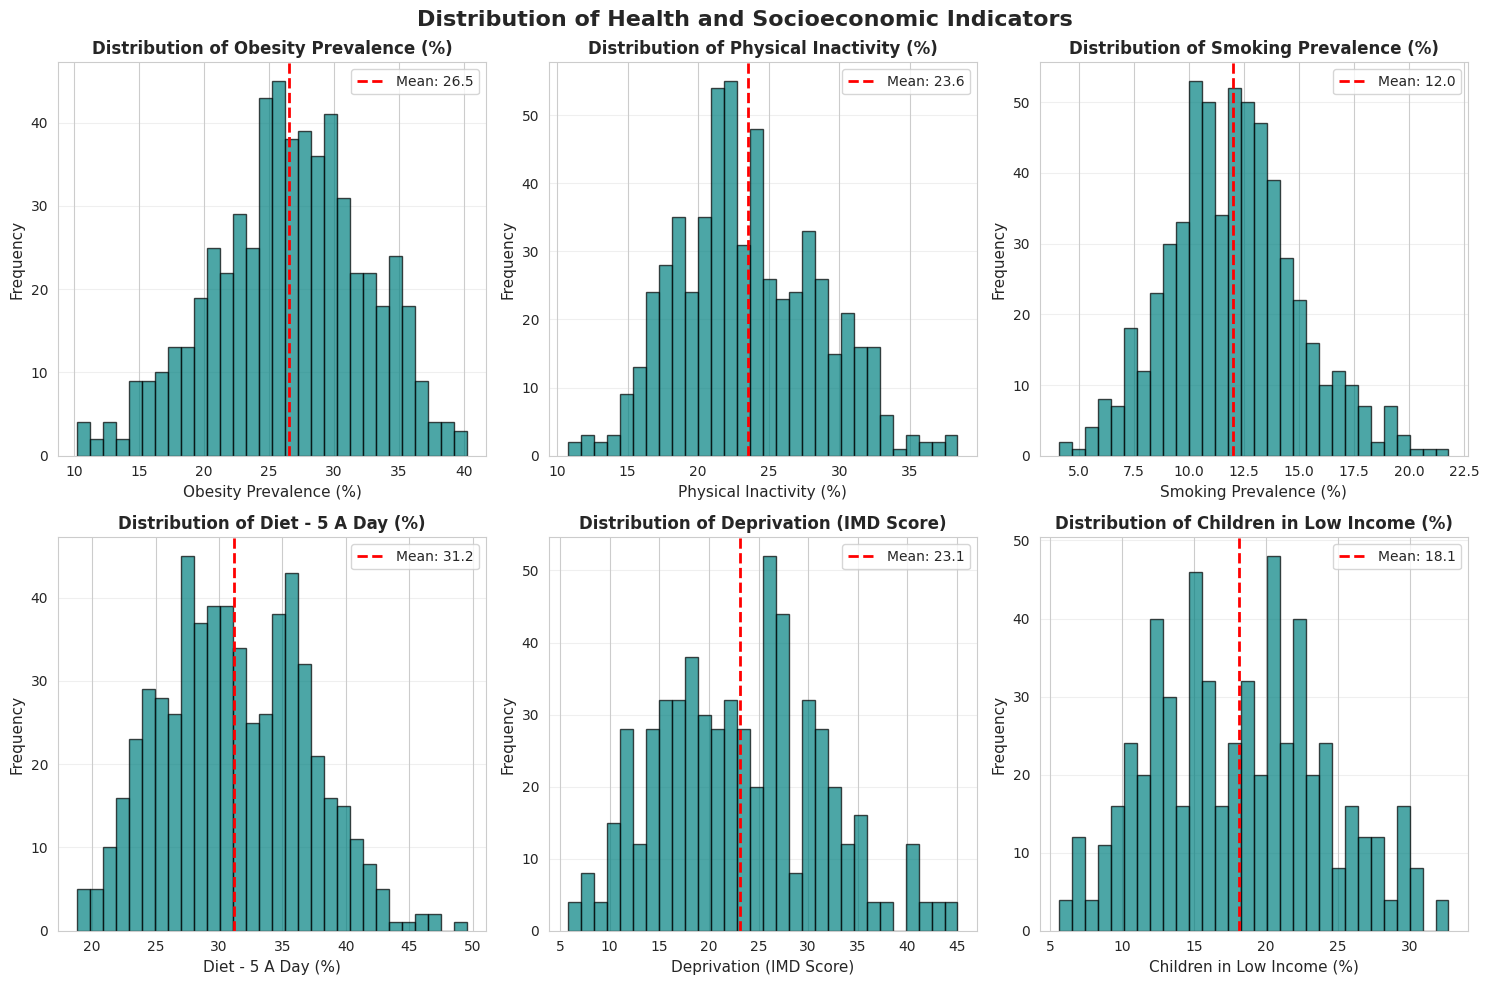

   ✓ Histogram saved: EDA_histogram_distributions.png


In [5]:
# Histogram - Distribution of all variables

print("EXPLORATORY DATA ANALYSIS")

print("\n1. Creating distribution histograms...")

# Define variables and labels
variables = {
    'obesity_prevalence': 'Obesity Prevalence (%)',
    'physical_inactivity': 'Physical Inactivity (%)',
    'smoking_prevalence': 'Smoking Prevalence (%)',
    'diet_5_a_day_pct': 'Diet - 5 A Day (%)',
    'imd_score': 'Deprivation (IMD Score)',
    'children_low_income_pct': 'Children in Low Income (%)'
}

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribution of Health and Socioeconomic Indicators',
             fontsize=16, fontweight='bold')

axes = axes.flatten()

# Plot histogram for each variable
for idx, (var, label) in enumerate(variables.items()):
    axes[idx].hist(df[var], bins=30, color='teal', edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(label, fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].set_title(f'Distribution of {label}', fontsize=12, fontweight='bold')
    axes[idx].grid(axis='y', alpha=0.3)

    # Add mean line
    mean_val = df[var].mean()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2,
                     label=f'Mean: {mean_val:.1f}')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EDA_histogram_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✓ Histogram saved: EDA_histogram_distributions.png")


INTERPRETATION:

All six variables show approximately symmetric distributions with no severe outliers, indicating acceptable data quality for modelling. Obesity prevalence (mean ≈ 26.5%) and physical inactivity (mean ≈ 23.6%) display relatively wide dispersion across Local Authorities, suggesting substantial geographic variation in health behaviours. Socioeconomic indicators, including deprivation (IMD score) and percentage of children in low-income households, also show considerable variability, confirming heterogeneity in area-level deprivation across England. Overall, the distributions appear suitable for regression-based modelling, although model assumptions should be verified using residual diagnostics.


2. Creating pairwise relationship plots...


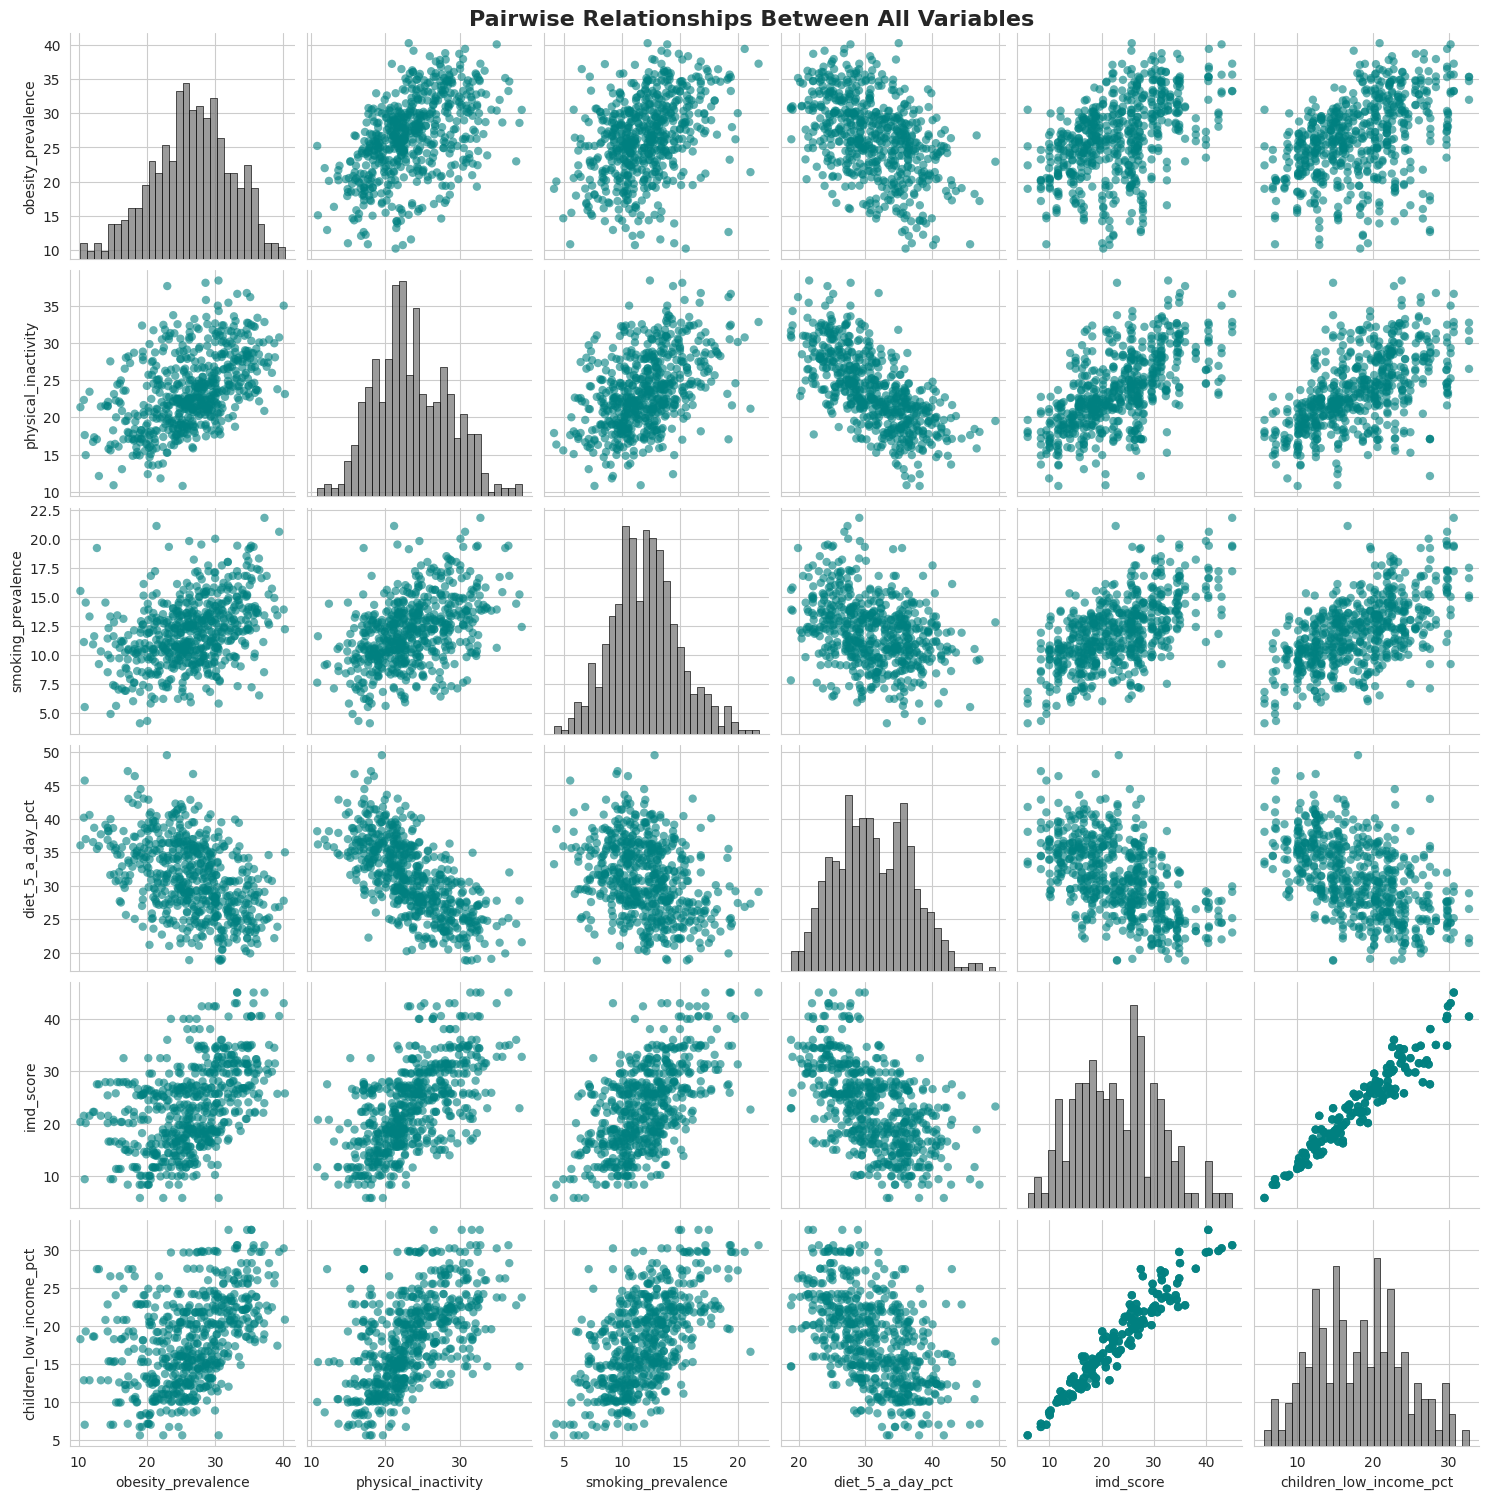

   ✓ Pairplot saved: EDA_pairwise_relationships.png


In [6]:
# Pairwise Relationships - Scatter plot matrix

print("\n2. Creating pairwise relationship plots...")

# Select variables for pairplot
plot_vars = ['obesity_prevalence', 'physical_inactivity', 'smoking_prevalence',
             'diet_5_a_day_pct', 'imd_score', 'children_low_income_pct']

# Create pairplot
pairplot = sns.pairplot(df[plot_vars],
                        diag_kind='hist',
                        plot_kws={'alpha': 0.6, 'edgecolor': 'none' , 'color': 'teal'},
                        diag_kws={'bins': 30, 'edgecolor': 'black' , 'color': '#7a7a7a'})

pairplot.fig.suptitle('Pairwise Relationships Between All Variables',
                      y=1.001, fontsize=16, fontweight='bold')

plt.savefig('/content/drive/MyDrive/EDA_pairwise_relationships.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✓ Pairplot saved: EDA_pairwise_relationships.png")


INTERPRETATION:

The pairplot reveals clear positive linear relationships between obesity prevalence and
both behavioral factors (physical inactivity, smoking) and socioeconomic determinants
(IMD score, children in low income). Diet (5-a-day) shows the expected negative correlation
with obesity. Notably, IMD and child poverty exhibit strong correlation (r=0.958), confirming
these socioeconomic variables capture overlapping but distinct aspects of area deprivation.
The linear patterns visible in scatter plots support the use of both linear and tree-based
regression models.


3. Correlation Analysis:

Correlation Matrix:
                         obesity_prevalence  physical_inactivity  smoking_prevalence  diet_5_a_day_pct  imd_score  children_low_income_pct
obesity_prevalence                    1.000                0.495               0.390            -0.464      0.482                    0.435
physical_inactivity                   0.495                1.000               0.452            -0.681      0.618                    0.572
smoking_prevalence                    0.390                0.452               1.000            -0.320      0.597                    0.578
diet_5_a_day_pct                     -0.464               -0.681              -0.320             1.000     -0.565                   -0.539
imd_score                             0.482                0.618               0.597            -0.565      1.000                    0.958
children_low_income_pct               0.435                0.572               0.578            -0.539      0.958      

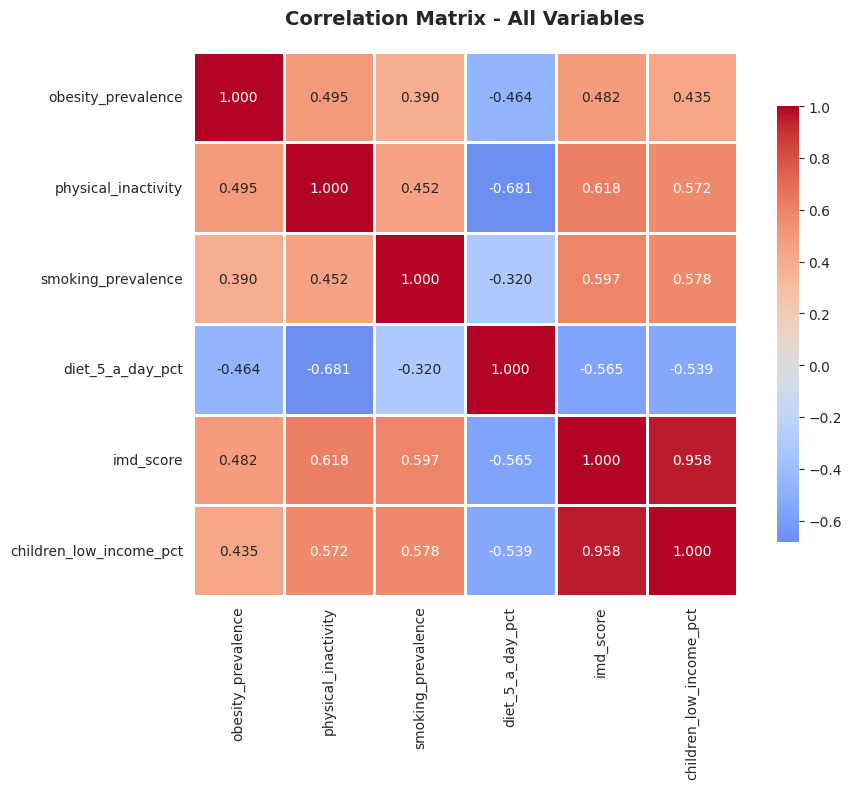


Correlations with Obesity Prevalence (ranked):
   physical_inactivity           : +0.495
   imd_score                     : +0.482
   children_low_income_pct       : +0.435
   smoking_prevalence            : +0.390
   diet_5_a_day_pct              : -0.464

   ✓ Correlation heatmap saved: EDA_correlation_matrix.png


In [7]:
# Correlation Analysis

print("\n3. Correlation Analysis:")

# Calculate correlation matrix
correlation_matrix = df[plot_vars].corr()

print("\nCorrelation Matrix:")
print(correlation_matrix.round(3))

# Create correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - All Variables', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EDA_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlations with obesity (target variable)
print("\nCorrelations with Obesity Prevalence (ranked):")
obesity_corr = correlation_matrix['obesity_prevalence'].sort_values(ascending=False)
for var, corr in obesity_corr.items():
    if var != 'obesity_prevalence':
        print(f"   {var:30s}: {corr:+.3f}")

print("\n   ✓ Correlation heatmap saved: EDA_correlation_matrix.png")


INTERPRETATION:

Physical inactivity shows the strongest correlation with obesity (r = 0.495), followed by diet quality (r = −0.464), indicating that higher fruit and vegetable intake is associated with lower obesity prevalence. Socioeconomic variables, including IMD score (r = 0.482) and percentage of children in low-income households (r = 0.435), show correlations comparable to behavioural factors, supporting their inclusion in the predictive model. A very strong correlation is observed between IMD and child poverty (r = 0.958), indicating potential multicollinearity; however, both variables were retained as they represent related but distinct aspects of area-level deprivation. Overall, the correlation patterns are consistent with theoretical expectations and previous public health research.

---
# Part 3: Data Preparation for Modeling

In [8]:
# Define Features and Target

print("DATA PREPARATION")

# Feature set (5 predictors)
feature_cols = [
    'physical_inactivity',      # Behavioral 1
    'smoking_prevalence',       # Behavioral 2
    'diet_5_a_day_pct',        # Behavioral 3
    'imd_score',               # Socioeconomic 1
    'children_low_income_pct'  # Socioeconomic 2
]

# Target variable
target_col = 'obesity_prevalence'

# Create feature matrix (X) and target vector (y)
X = df[feature_cols]
y = df[target_col]

print(f"\nFeatures (X): {X.shape}")
print(f"   Behavioral features: 3")
print(f"   Socioeconomic features: 2")
print(f"\nTarget (y): {y.shape}")
print(f"   Target variable: {target_col}")

DATA PREPARATION

Features (X): (583, 5)
   Behavioral features: 3
   Socioeconomic features: 2

Target (y): (583,)
   Target variable: obesity_prevalence


In [9]:
# Train-Test Split

print("\nSplitting data into training and test sets...")

# Split data: 80% training, 20% testing
# random_state=50 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=50     # For reproducibility
)

print(f"\nTraining set: {len(X_train)} observations ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test)} observations ({len(X_test)/len(X)*100:.1f}%)")


Splitting data into training and test sets...

Training set: 466 observations (79.9%)
Test set: 117 observations (20.1%)


In [10]:
# Feature Scaling (Standardization)

print("\nScaling features (standardization)...")

# Initialize StandardScaler
# This transforms features to have mean=0 and std=1
scaler = StandardScaler()

# Fit scaler on training data and transform both sets
# IMPORTANT: Fit only on training data to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeatures standardized (mean=0, std=1)")
print(f"Scaling prevents features with larger ranges from dominating")

# Verify scaling
print(f"\nTraining set after scaling:")
print(f"   Mean: {X_train_scaled.mean(axis=0).round(4)}")
print(f"   Std: {X_train_scaled.std(axis=0).round(4)}")

print("DATA PREPARATION COMPLETE")


Scaling features (standardization)...

Features standardized (mean=0, std=1)
Scaling prevents features with larger ranges from dominating

Training set after scaling:
   Mean: [ 0. -0. -0. -0. -0.]
   Std: [1. 1. 1. 1. 1.]
DATA PREPARATION COMPLETE


In [11]:
# PART 3B: HYPERPARAMETER TUNING (GridSearchCV)

from sklearn.model_selection import GridSearchCV, KFold
import warnings
warnings.filterwarnings('ignore')

print("PART 4B: HYPERPARAMETER TUNING (GridSearchCV)")
print("Searching for optimal parameters for all 4 models...")
print("This may take a few minutes...")

# Define consistent cross-validation strategy
kfold = KFold(n_splits=5, shuffle=True, random_state=50)

# ---- Lasso Tuning ----
print("\nTuning Lasso Regression...")
lasso_param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}
lasso_grid = GridSearchCV(
    Lasso(random_state=50),
    lasso_param_grid,
    cv=kfold, scoring='r2', n_jobs=-1
)
lasso_grid.fit(X_train_scaled, y_train)
print(f"  Best Parameters: {lasso_grid.best_params_}")
print(f"  Best CV R2:      {lasso_grid.best_score_:.4f}")

# ---- Ridge Tuning ----
print("\nTuning Ridge Regression...")
ridge_param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}
ridge_grid = GridSearchCV(
    Ridge(),
    ridge_param_grid,
    cv=kfold, scoring='r2', n_jobs=-1
)
ridge_grid.fit(X_train_scaled, y_train)
print(f"  Best Parameters: {ridge_grid.best_params_}")
print(f"  Best CV R2:      {ridge_grid.best_score_:.4f}")

# ---- Random Forest Tuning ----
print("\nTuning Random Forest...")
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': [0.5, 0.75, 1.0]
}
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=50, n_jobs=-1),
    rf_param_grid,
    cv=kfold, scoring='r2', n_jobs=-1
)
rf_grid.fit(X_train_scaled, y_train)
print(f"  Best Parameters: {rf_grid.best_params_}")
print(f"  Best CV R2:      {rf_grid.best_score_:.4f}")

# ---- Gradient Boosting Tuning ----
print("\nTuning Gradient Boosting (with regularisation)...")
gb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_samples_split': [10, 20, 30],
    'subsample': [0.7, 0.8, 0.9],
    'max_features': [0.7, 0.8, 1.0]
}
gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=50),
    gb_param_grid,
    cv=kfold, scoring='r2', n_jobs=-1
)
gb_grid.fit(X_train_scaled, y_train)
print(f"  Best Parameters: {gb_grid.best_params_}")
print(f"  Best CV R2:      {gb_grid.best_score_:.4f}")

# ---- Summary ----
print("HYPERPARAMETER TUNING SUMMARY")
print(f"  Lasso:             alpha={lasso_grid.best_params_['alpha']},  CV R2={lasso_grid.best_score_:.4f}")
print(f"  Ridge:             alpha={ridge_grid.best_params_['alpha']},  CV R2={ridge_grid.best_score_:.4f}")
print(f"  Random Forest:     {rf_grid.best_params_},  CV R2={rf_grid.best_score_:.4f}")
print(f"  Gradient Boosting: {gb_grid.best_params_},  CV R2={gb_grid.best_score_:.4f}")
print("\nOptimal parameters will be used in model training")


PART 4B: HYPERPARAMETER TUNING (GridSearchCV)
Searching for optimal parameters for all 4 models...
This may take a few minutes...

Tuning Lasso Regression...
  Best Parameters: {'alpha': 0.1}
  Best CV R2:      0.2789

Tuning Ridge Regression...
  Best Parameters: {'alpha': 10.0}
  Best CV R2:      0.2777

Tuning Random Forest...
  Best Parameters: {'max_depth': 15, 'max_features': 0.5, 'min_samples_split': 2, 'n_estimators': 300}
  Best CV R2:      0.4388

Tuning Gradient Boosting (with regularisation)...
  Best Parameters: {'learning_rate': 0.2, 'max_depth': 4, 'max_features': 0.8, 'min_samples_split': 20, 'n_estimators': 300, 'subsample': 0.8}
  Best CV R2:      0.5080
HYPERPARAMETER TUNING SUMMARY
  Lasso:             alpha=0.1,  CV R2=0.2789
  Ridge:             alpha=10.0,  CV R2=0.2777
  Random Forest:     {'max_depth': 15, 'max_features': 0.5, 'min_samples_split': 2, 'n_estimators': 300},  CV R2=0.4388
  Gradient Boosting: {'learning_rate': 0.2, 'max_depth': 4, 'max_features': 

**Interpretation** — **Hyperparameter** **Tuning**

Hyperparameter tuning was performed using GridSearchCV with 5-fold cross-validation to identify the optimal settings for each model. Four regression models were evaluated: Lasso, Ridge, Random Forest, and Gradient Boosting. For each model, a range of hyperparameters was tested, and the combination producing the highest cross-validated R² score was selected.
The results showed that the linear models (Lasso and Ridge) achieved relatively low predictive performance (R² ≈ 0.28), indicating that simple linear relationships were not sufficient to fully explain variation in obesity prevalence across local authorities. In contrast, the tree-based models performed better, with Random Forest achieving a cross-validated R² of 0.44 and Gradient Boosting achieving the highest performance (R² = 0.51).
The superior performance of tree-based models suggests that the relationship between obesity prevalence and the behavioural and socioeconomic predictors is likely non-linear and involves interactions between variables. Gradient Boosting provided the best overall performance after tuning, and the optimal hyperparameters identified by GridSearchCV were therefore used for the final model training and evaluation.

# Part 4: Model Training and Evaluation

I will train and evaluate 4 machine learning models:
1. **Lasso Regression** (L1 regularization)
2. **Ridge Regression** (L2 regularization)
3. **Random Forest** (Ensemble method)
4. **Gradient Boosting** (Sequential ensemble)

**Each model includes:**
- Performance metrics (R², RMSE, MAE, CV scores)
- Actual vs Predicted plot
- Residual analysis plot
- Residual distribution plot
- Feature coefficients/importance visualization

## Model 1: Lasso Regression

In [12]:
# MODEL 1: LASSO REGRESSION
# Linear regression with L1 regularization (can perform feature selection)
# Parameters selected via GridSearchCV (Part 4B)

print("MODEL 1: LASSO REGRESSION")

print("\nLasso Regression:")
print("   - Linear regression with L1 regularization")
print("   - Can shrink some coefficients to zero (feature selection)")
print("   - Good when some features may be irrelevant")

# Train Lasso model with optimal parameters from GridSearch
print("\n1. Training Lasso model with optimal parameters...")
lasso = Lasso(
    alpha=lasso_grid.best_params_['alpha'],   # Optimal from GridSearchCV
    random_state=50
)
lasso.fit(X_train_scaled, y_train)
print(f"   Model trained successfully (alpha={lasso_grid.best_params_['alpha']})")

# Make predictions
print("\n2. Making predictions...")
y_pred_lasso = lasso.predict(X_test_scaled)

# Calculate metrics
print("\n3. Calculating performance metrics...")
r2_lasso = r2_score(y_test, y_pred_lasso)
n = len(y_test)
p = len(feature_cols)
adj_r2_lasso = 1 - (1 - r2_lasso) * (n - 1) / (n - p - 1)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

# Cross-validation using consistent kfold
cv_scores_lasso = cross_val_score(lasso, X_train_scaled, y_train,
                                   cv=kfold, scoring='r2')
cv_r2_lasso = cv_scores_lasso.mean()
cv_std_lasso = cv_scores_lasso.std()

# Calculate residuals
residuals_lasso = y_test - y_pred_lasso

# Display results
print("\n4. Lasso Regression Results:")
print(f"   R2 Score: {r2_lasso:.4f} ({r2_lasso*100:.2f}% variance explained)")
print(f"   Adjusted R2: {adj_r2_lasso:.4f}")
print(f"   RMSE: {rmse_lasso:.2f} percentage points")
print(f"   MAE: {mae_lasso:.2f} percentage points")
print(f"   Cross-Validation R2: {cv_r2_lasso:.4f} (+-{cv_std_lasso:.4f})")

# Feature coefficients
print("\n5. Feature Coefficients:")
coefficients_lasso = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lasso.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(coefficients_lasso.to_string(index=False))

# Check for feature selection
zero_coef = (lasso.coef_ == 0).sum()
if zero_coef > 0:
    print(f"\n   Note: Lasso set {zero_coef} coefficient(s) to zero (feature selection)")
else:
    print(f"\n   Note: All features retained (no coefficients set to zero)")


MODEL 1: LASSO REGRESSION

Lasso Regression:
   - Linear regression with L1 regularization
   - Can shrink some coefficients to zero (feature selection)
   - Good when some features may be irrelevant

1. Training Lasso model with optimal parameters...
   Model trained successfully (alpha=0.1)

2. Making predictions...

3. Calculating performance metrics...

4. Lasso Regression Results:
   R2 Score: 0.4065 (40.65% variance explained)
   Adjusted R2: 0.3798
   RMSE: 4.94 percentage points
   MAE: 4.15 percentage points
   Cross-Validation R2: 0.2789 (+-0.0324)

5. Feature Coefficients:
                Feature  Coefficient
       diet_5_a_day_pct    -1.163023
    physical_inactivity     1.015024
     smoking_prevalence     0.776875
              imd_score     0.685253
children_low_income_pct    -0.000000

   Note: Lasso set 1 coefficient(s) to zero (feature selection)



6. Creating Lasso visualizations...


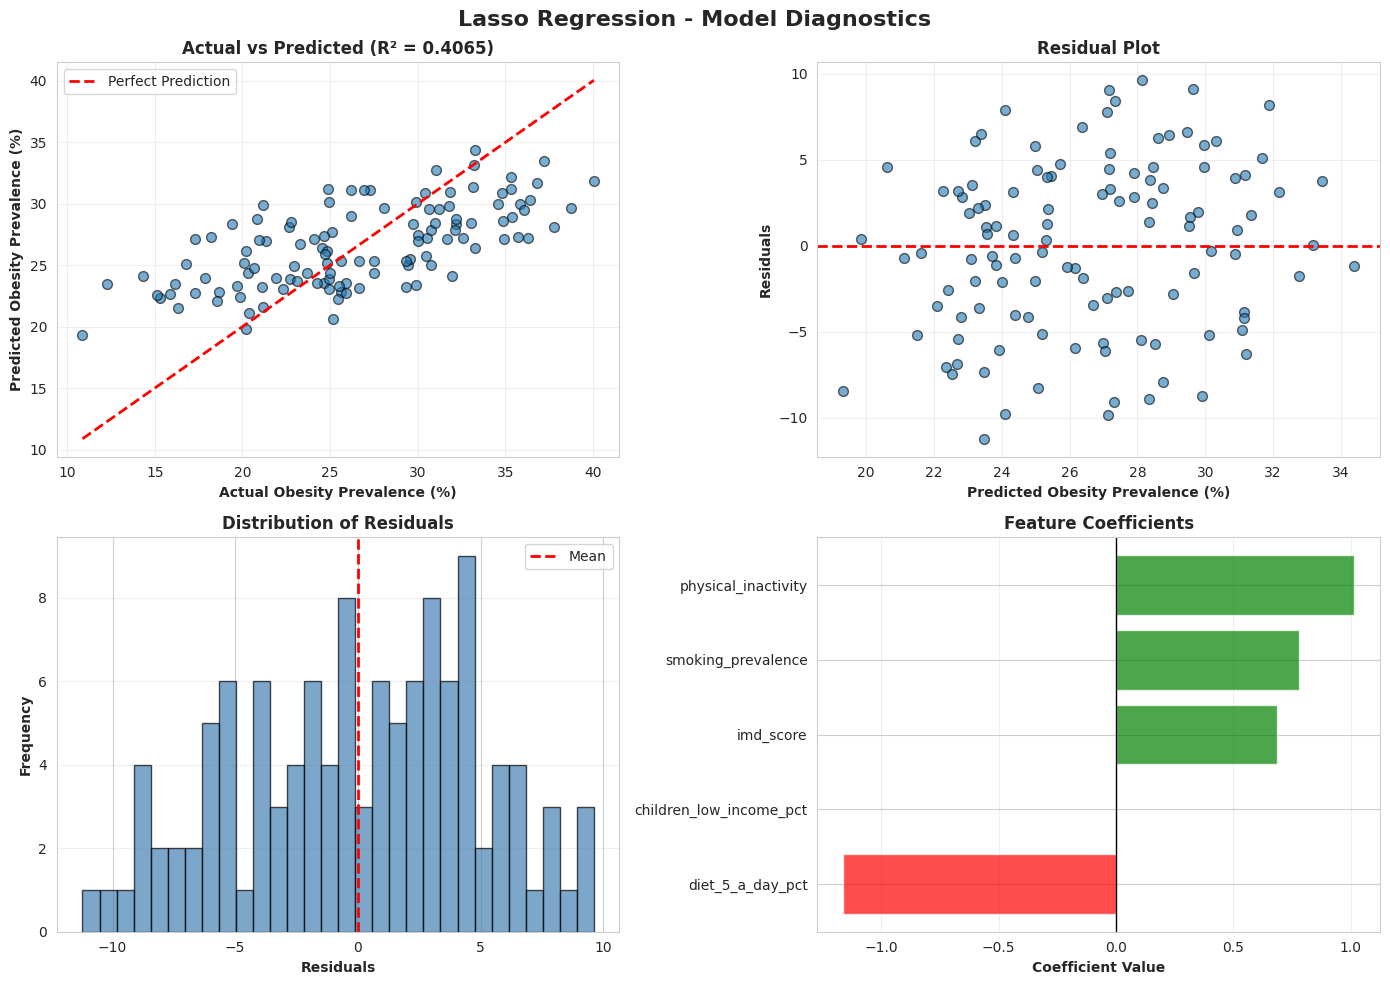

   ✓ Lasso diagnostics saved: Model1_Lasso_Diagnostics.png
LASSO REGRESSION COMPLETE


In [13]:
# LASSO VISUALIZATIONS

print("\n6. Creating Lasso visualizations...")

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Lasso Regression - Model Diagnostics', fontsize=16, fontweight='bold')

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred_lasso, alpha=0.6, edgecolors='k', s=50)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Obesity Prevalence (%)', fontweight='bold')
axes[0, 0].set_ylabel('Predicted Obesity Prevalence (%)', fontweight='bold')
axes[0, 0].set_title(f'Actual vs Predicted (R² = {r2_lasso:.4f})', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Residual Plot
axes[0, 1].scatter(y_pred_lasso, residuals_lasso, alpha=0.6, edgecolors='k', s=50)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Obesity Prevalence (%)', fontweight='bold')
axes[0, 1].set_ylabel('Residuals', fontweight='bold')
axes[0, 1].set_title('Residual Plot', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Residual Distribution
axes[1, 0].hist(residuals_lasso, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 0].set_xlabel('Residuals', fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontweight='bold')
axes[1, 0].set_title('Distribution of Residuals', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Feature Coefficients
coef_sorted = coefficients_lasso.sort_values('Coefficient')
colors_coef = ['green' if c > 0 else 'red' for c in coef_sorted['Coefficient']]
axes[1, 1].barh(coef_sorted['Feature'], coef_sorted['Coefficient'], color=colors_coef, alpha=0.7)
axes[1, 1].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[1, 1].set_xlabel('Coefficient Value', fontweight='bold')
axes[1, 1].set_title('Feature Coefficients', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Model1_Lasso_Diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✓ Lasso diagnostics saved: Model1_Lasso_Diagnostics.png")

print("LASSO REGRESSION COMPLETE")

# cross validation
cv_scores_lasso = cross_val_score(lasso, X_train_scaled, y_train, cv=kfold, scoring='r2')
cv_r2_lasso = cv_scores_lasso.mean()
cv_std_lasso = cv_scores_lasso.std()

# LASSO REGRESSION — COMPLETE DIAGNOSTIC ANALYSIS

---

## Performance Metrics

| Metric | Value |
|---|---|
| Test R² | 0.4065 (40.65% variance explained) |
| Adjusted R² | 0.3798 |
| RMSE | 4.9354 percentage points |
| MAE | 4.1509 percentage points |
| CV R² | 0.2789 (±0.0324) |

- Weakest performer among the four models
- CV R² of 0.2789 indicates poor generalisation to unseen Local Authorities
- alpha = 0.1 selected via GridSearchCV

---

## Feature Coefficients

| Rank | Feature | Coefficient | Type |
|---|---|---|---|
| 1st | diet_5_a_day_pct | -1.1630 | Behavioural |
| 2nd | physical_inactivity | +1.0150 | Behavioural |
| 3rd | smoking_prevalence | +0.7769 | Behavioural |
| 4th | imd_score | +0.6853 | Socioeconomic |
| 5th | children_low_income_pct | 0.0000 | Socioeconomic |

---

## Feature Selection

- Lasso eliminated **children_low_income_pct** (set to zero)
- Demonstrates Lasso's built-in L1 feature selection capability
- children_low_income_pct adds no unique predictive value beyond
  what IMD already captures — consistent with their high correlation

---

## Why children_low_income_pct Was Eliminated

Lasso applies L1 regularisation which shrinks less important coefficients
to exactly zero. Since children_low_income_pct is highly correlated with
imd_score, both capture similar deprivation information. Lasso identifies
imd_score as the more informative predictor and eliminates
children_low_income_pct automatically.

---

## Overall Assessment

- Lasso provides a useful baseline but underfits the data
- Linear assumptions cannot capture complex non-linear relationships
  between behavioural and socioeconomic factors and obesity prevalence
- The elimination of children_low_income_pct informs subsequent
  multicollinearity interpretation


## Model 2: Ridge Regression

In [14]:
# MODEL 2: RIDGE REGRESSION
# Linear regression with L2 regularization (shrinks all coefficients)
# Parameters selected via GridSearchCV (Part 4B)

print("MODEL 2: RIDGE REGRESSION")

print("\nRidge Regression:")
print("   - Linear regression with L2 regularization")
print("   - Prevents overfitting by penalizing large coefficients")
print("   - Good baseline linear model")

# Train Ridge model with optimal parameters from GridSearch
print("\n1. Training Ridge model with optimal parameters...")
ridge = Ridge(
    alpha=ridge_grid.best_params_['alpha']    # Optimal from GridSearchCV
)
ridge.fit(X_train_scaled, y_train)
print(f"   Model trained successfully (alpha={ridge_grid.best_params_['alpha']})")

# Make predictions
print("\n2. Making predictions...")
y_pred_ridge = ridge.predict(X_test_scaled)

# Calculate metrics
print("\n3. Calculating performance metrics...")
r2_ridge = r2_score(y_test, y_pred_ridge)
adj_r2_ridge = 1 - (1 - r2_ridge) * (n - 1) / (n - p - 1)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
cv_scores_ridge = cross_val_score(ridge, X_train_scaled, y_train,
                                   cv=kfold, scoring='r2')
cv_r2_ridge = cv_scores_ridge.mean()
cv_std_ridge = cv_scores_ridge.std()

# Calculate residuals
residuals_ridge = y_test - y_pred_ridge

# Display results
print("\n4. Ridge Regression Results:")
print(f"   R2 Score: {r2_ridge:.4f} ({r2_ridge*100:.2f}% variance explained)")
print(f"   Adjusted R2: {adj_r2_ridge:.4f}")
print(f"   RMSE: {rmse_ridge:.2f} percentage points")
print(f"   MAE: {mae_ridge:.2f} percentage points")
print(f"   Cross-Validation R2: {cv_scores_ridge.mean():.4f} (+-{cv_scores_ridge.std():.4f})")

# Feature coefficients
print("\n5. Feature Coefficients:")
coefficients_ridge = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': ridge.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(coefficients_ridge.to_string(index=False))


MODEL 2: RIDGE REGRESSION

Ridge Regression:
   - Linear regression with L2 regularization
   - Prevents overfitting by penalizing large coefficients
   - Good baseline linear model

1. Training Ridge model with optimal parameters...
   Model trained successfully (alpha=10.0)

2. Making predictions...

3. Calculating performance metrics...

4. Ridge Regression Results:
   R2 Score: 0.4186 (41.86% variance explained)
   Adjusted R2: 0.3924
   RMSE: 4.88 percentage points
   MAE: 4.10 percentage points
   Cross-Validation R2: 0.2777 (+-0.0380)

5. Feature Coefficients:
                Feature  Coefficient
              imd_score     1.361724
       diet_5_a_day_pct    -1.219634
    physical_inactivity     1.020496
     smoking_prevalence     0.855937
children_low_income_pct    -0.717785



6. Creating Ridge visualizations...


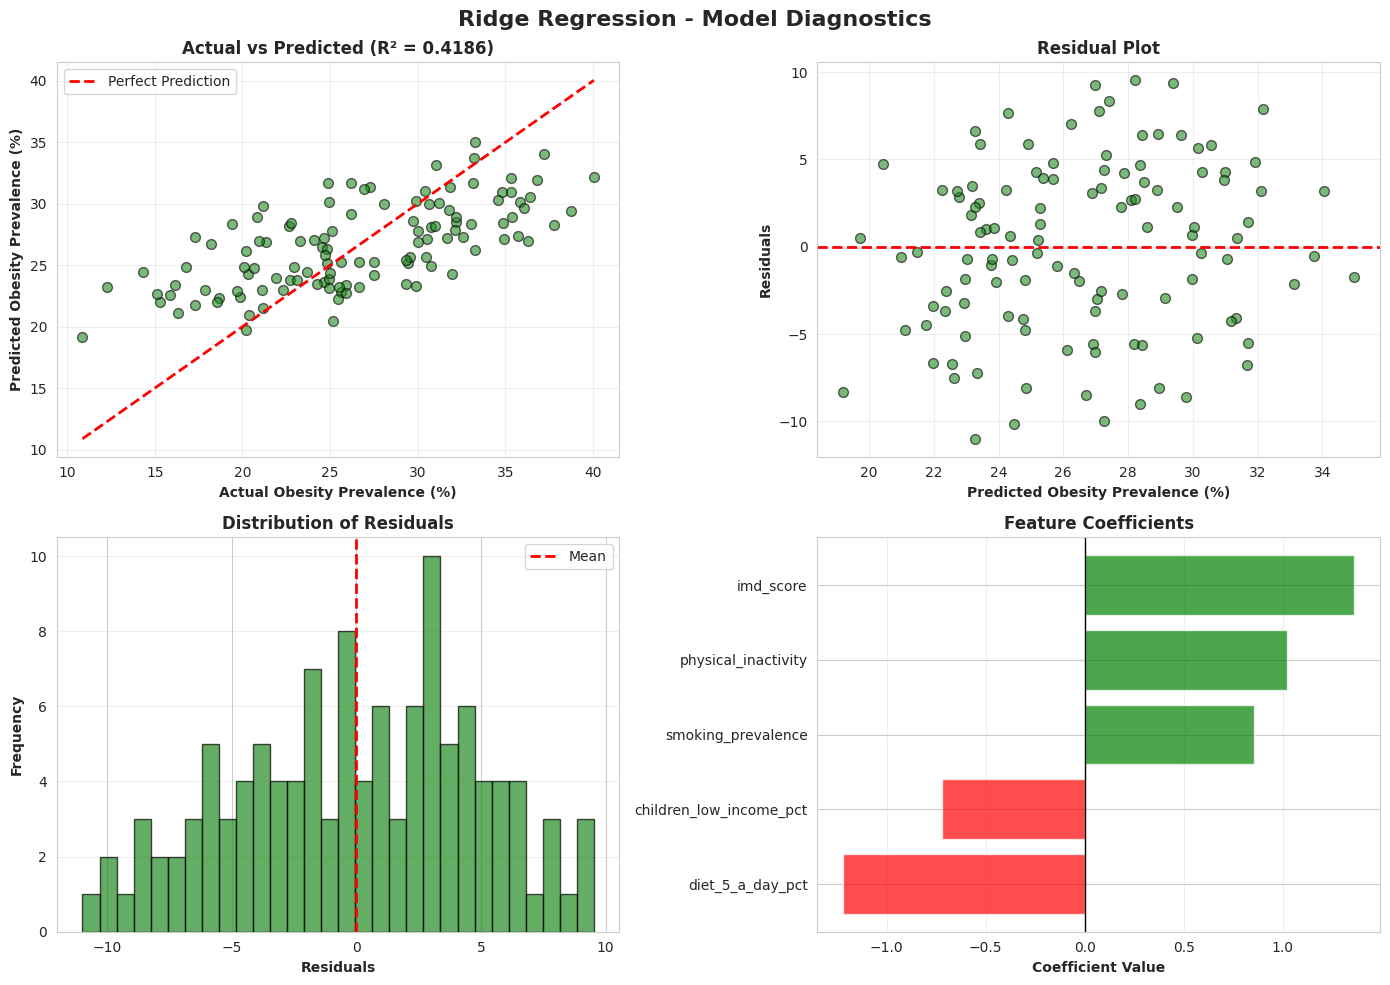

   ✓ Ridge diagnostics saved: Model2_Ridge_Diagnostics.png
RIDGE REGRESSION COMPLETE


In [15]:
# RIDGE VISUALIZATIONS

print("\n6. Creating Ridge visualizations...")

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Ridge Regression - Model Diagnostics', fontsize=16, fontweight='bold')

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred_ridge, alpha=0.6, edgecolors='k', s=50, color='forestgreen')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Obesity Prevalence (%)', fontweight='bold')
axes[0, 0].set_ylabel('Predicted Obesity Prevalence (%)', fontweight='bold')
axes[0, 0].set_title(f'Actual vs Predicted (R² = {r2_ridge:.4f})', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Residual Plot
axes[0, 1].scatter(y_pred_ridge, residuals_ridge, alpha=0.6, edgecolors='k', s=50, color='forestgreen')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Obesity Prevalence (%)', fontweight='bold')
axes[0, 1].set_ylabel('Residuals', fontweight='bold')
axes[0, 1].set_title('Residual Plot', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Residual Distribution
axes[1, 0].hist(residuals_ridge, bins=30, color='forestgreen', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 0].set_xlabel('Residuals', fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontweight='bold')
axes[1, 0].set_title('Distribution of Residuals', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Feature Coefficients
coef_sorted = coefficients_ridge.sort_values('Coefficient')
colors_coef = ['green' if c > 0 else 'red' for c in coef_sorted['Coefficient']]
axes[1, 1].barh(coef_sorted['Feature'], coef_sorted['Coefficient'], color=colors_coef, alpha=0.7)
axes[1, 1].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[1, 1].set_xlabel('Coefficient Value', fontweight='bold')
axes[1, 1].set_title('Feature Coefficients', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Model2_Ridge_Diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✓ Ridge diagnostics saved: Model2_Ridge_Diagnostics.png")
print("RIDGE REGRESSION COMPLETE")

# RIDGE REGRESSION — COMPLETE DIAGNOSTIC ANALYSIS

---

## Performance Metrics

| Metric | Value |
|---|---|
| Test R² | 0.4186 (41.86% variance explained) |
| Adjusted R² | 0.3924 |
| RMSE | 4.8846 percentage points |
| MAE | 4.1017 percentage points |
| CV R² | 0.2777 (±0.0380) |

- Marginal improvement over Lasso (+1.21 percentage points)
- CV R² of 0.2777 — still weak generalisation
- alpha = 10.0 selected via GridSearchCV

---

## Feature Coefficients

| Rank | Feature | Coefficient | Type |
|---|---|---|---|
| 1st | imd_score | +1.3617 | Socioeconomic |
| 2nd | diet_5_a_day_pct | -1.2196 | Behavioural |
| 3rd | physical_inactivity | +1.0205 | Behavioural |
| 4th | smoking_prevalence | +0.8559 | Behavioural |
| 5th | children_low_income_pct | -0.7178 | Socioeconomic |

---

## Why Is children_low_income_pct Negative?

This is a **suppression effect caused by multicollinearity**.
children_low_income_pct and imd_score are highly correlated — both
measure socioeconomic deprivation. When both are present, imd_score
absorbs most of the shared deprivation signal, leaving
children_low_income_pct with a residual negative coefficient.

This does NOT mean children in low income households are protected from
obesity — it reflects a statistical artefact of correlated predictors
in linear models. SHAP analysis provides a more reliable estimate of
each predictor's true contribution by measuring marginal impact
independently.

---

## Overall Assessment

- Ridge retains all five predictors unlike Lasso
- CV R² (0.2777) confirms poor generalisation to unseen Local Authorities
- Ensemble methods expected to substantially improve performance


## Model 3: Random Forest

In [16]:
# MODEL 3: RANDOM FOREST REGRESSOR
# Ensemble of decision trees (captures non-linear relationships)
# Parameters selected via GridSearchCV (Part 4B)

print("MODEL 3: RANDOM FOREST REGRESSOR")

print("\nRandom Forest:")
print("   - Ensemble of decision trees")
print("   - Captures non-linear relationships")
print("   - Handles feature interactions automatically")

# Train Random Forest with optimal parameters from GridSearch
print("\n1. Training Random Forest model with optimal parameters...")
rf = RandomForestRegressor(
    n_estimators=rf_grid.best_params_['n_estimators'],     # Optimal from GridSearchCV
    max_depth=rf_grid.best_params_['max_depth'],           # Optimal from GridSearchCV
    min_samples_split=rf_grid.best_params_['min_samples_split'],  # Optimal from GridSearchCV
    max_features=rf_grid.best_params_['max_features'],     # Optimal from GridSearchCV
    random_state=50,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)
print(f"   Model trained with {rf.n_estimators} trees")
print(f"   Parameters: {rf_grid.best_params_}")

# Make predictions
print("\n2. Making predictions...")
y_pred_rf = rf.predict(X_test_scaled)

# Calculate metrics
print("\n3. Calculating performance metrics...")
r2_rf = r2_score(y_test, y_pred_rf)
adj_r2_rf = 1 - (1 - r2_rf) * (n - 1) / (n - p - 1)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
cv_scores_rf = cross_val_score(rf, X_train_scaled, y_train,
                                cv=kfold, scoring='r2')
cv_r2_rf = cv_scores_rf.mean()
cv_std_rf = cv_scores_rf.std()

# Calculate residuals
residuals_rf = y_test - y_pred_rf

# Display results
print("\n4. Random Forest Results:")
print(f"   R2 Score: {r2_rf:.4f} ({r2_rf*100:.2f}% variance explained)")
print(f"   Adjusted R2: {adj_r2_rf:.4f}")
print(f"   RMSE: {rmse_rf:.2f} percentage points")
print(f"   MAE: {mae_rf:.2f} percentage points")
print(f"   Cross-Validation R2: {cv_scores_rf.mean():.4f} (+-{cv_scores_rf.std():.4f})")

# Feature importance
print("\n5. Feature Importance:")
feature_importance_rf = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print(feature_importance_rf.to_string(index=False))

# Behavioral vs socioeconomic contributions
behavioral_importance = feature_importance_rf[
    feature_importance_rf['Feature'].isin(['physical_inactivity', 'smoking_prevalence', 'diet_5_a_day_pct'])
]['Importance'].sum()
socioeconomic_importance = feature_importance_rf[
    feature_importance_rf['Feature'].isin(['imd_score', 'children_low_income_pct'])
]['Importance'].sum()
print(f"\n   Behavioral features contribution: {behavioral_importance*100:.1f}%")
print(f"   Socioeconomic features contribution: {socioeconomic_importance*100:.1f}%")


MODEL 3: RANDOM FOREST REGRESSOR

Random Forest:
   - Ensemble of decision trees
   - Captures non-linear relationships
   - Handles feature interactions automatically

1. Training Random Forest model with optimal parameters...
   Model trained with 300 trees
   Parameters: {'max_depth': 15, 'max_features': 0.5, 'min_samples_split': 2, 'n_estimators': 300}

2. Making predictions...

3. Calculating performance metrics...

4. Random Forest Results:
   R2 Score: 0.6012 (60.12% variance explained)
   Adjusted R2: 0.5833
   RMSE: 4.05 percentage points
   MAE: 3.22 percentage points
   Cross-Validation R2: 0.4388 (+-0.0492)

5. Feature Importance:
                Feature  Importance
              imd_score    0.257316
    physical_inactivity    0.245792
children_low_income_pct    0.191676
       diet_5_a_day_pct    0.180467
     smoking_prevalence    0.124748

   Behavioral features contribution: 55.1%
   Socioeconomic features contribution: 44.9%



6. Creating Random Forest visualizations...


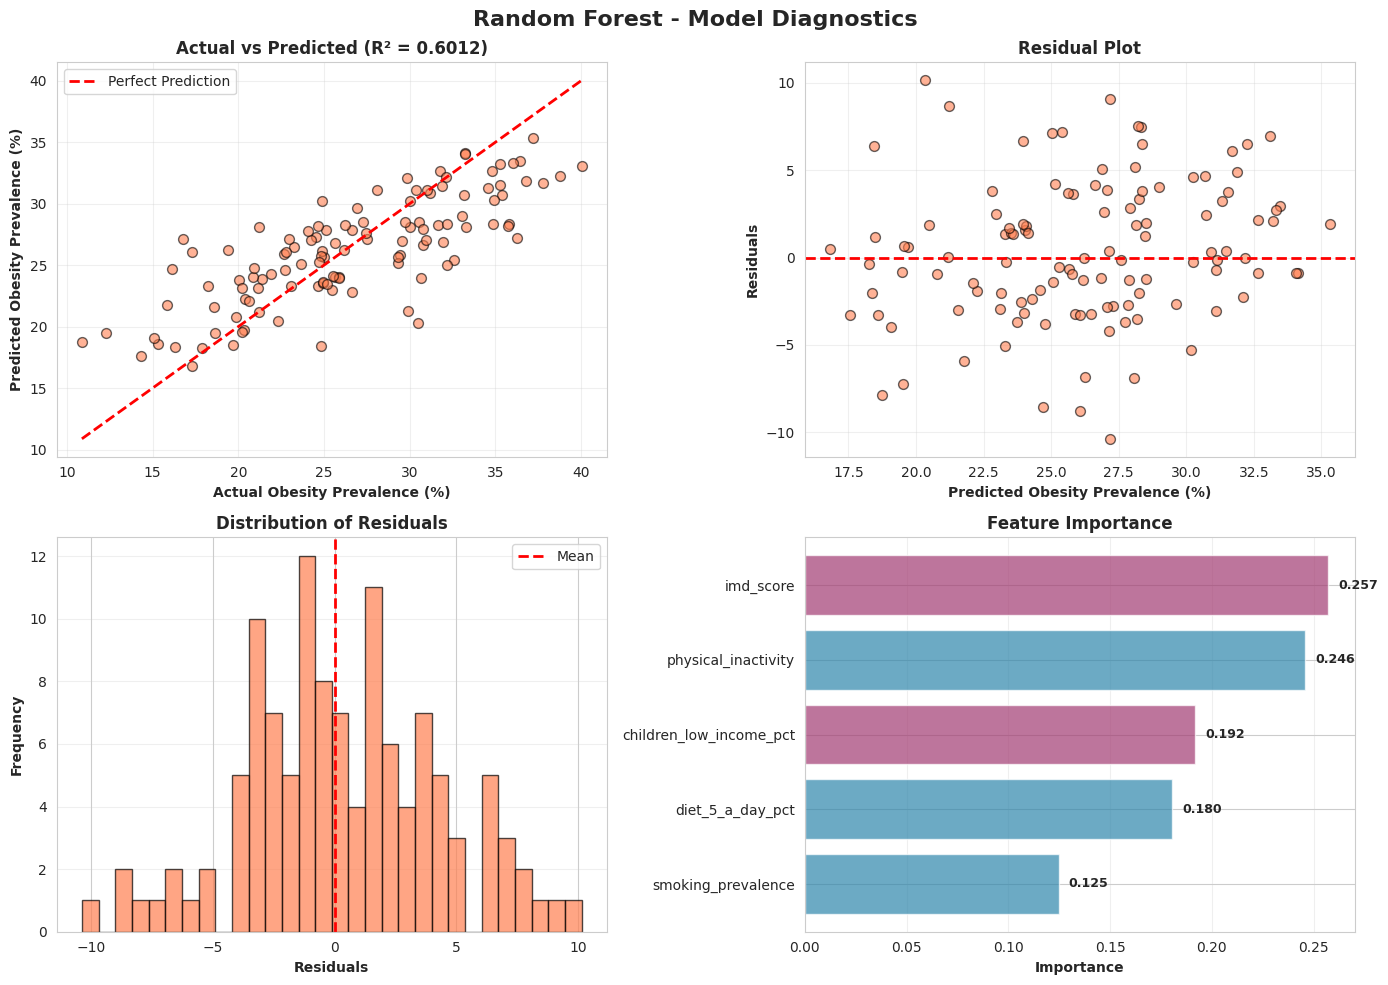

   ✓ Random Forest diagnostics saved: Model3_RandomForest_Diagnostics.png
RANDOM FOREST COMPLETE


In [17]:
# RANDOM FOREST VISUALIZATIONS

print("\n6. Creating Random Forest visualizations...")

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Random Forest - Model Diagnostics', fontsize=16, fontweight='bold')

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred_rf, alpha=0.6, edgecolors='k', s=50, color='coral')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Obesity Prevalence (%)', fontweight='bold')
axes[0, 0].set_ylabel('Predicted Obesity Prevalence (%)', fontweight='bold')
axes[0, 0].set_title(f'Actual vs Predicted (R² = {r2_rf:.4f})', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Residual Plot
axes[0, 1].scatter(y_pred_rf, residuals_rf, alpha=0.6, edgecolors='k', s=50, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Obesity Prevalence (%)', fontweight='bold')
axes[0, 1].set_ylabel('Residuals', fontweight='bold')
axes[0, 1].set_title('Residual Plot', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Residual Distribution
axes[1, 0].hist(residuals_rf, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 0].set_xlabel('Residuals', fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontweight='bold')
axes[1, 0].set_title('Distribution of Residuals', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Feature Importance
feature_importance_rf_sorted = feature_importance_rf.sort_values('Importance', ascending=True)
colors_importance = ['#2E86AB' if feat in ['physical_inactivity', 'smoking_prevalence', 'diet_5_a_day_pct']
                     else '#A23B72' for feat in feature_importance_rf_sorted['Feature']]
axes[1, 1].barh(feature_importance_rf_sorted['Feature'],
                feature_importance_rf_sorted['Importance'],
                color=colors_importance, alpha=0.7)
axes[1, 1].set_xlabel('Importance', fontweight='bold')
axes[1, 1].set_title('Feature Importance', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

# Add value labels correctly
for i, (idx, row) in enumerate(feature_importance_rf_sorted.iterrows()):
    axes[1, 1].text(row['Importance'] + 0.005, i,
                    f"{row['Importance']:.3f}",
                    va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Model3_RandomForest_Diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✓ Random Forest diagnostics saved: Model3_RandomForest_Diagnostics.png")

print("RANDOM FOREST COMPLETE")

# RANDOM FOREST — COMPLETE DIAGNOSTIC ANALYSIS

---

## Performance Metrics

| Metric | Value |
|---|---|
| Test R² | 0.6012 (60.12% variance explained) |
| Adjusted R² | 0.5833 |
| RMSE | 4.0455 percentage points |
| MAE | 3.2166 percentage points |
| CV R² | 0.4388 (±0.0492) |

- Strong improvement over Ridge (+18.26 percentage points)
- Strong improvement over Lasso (+19.47 percentage points)
- Second best CV R² after Gradient Boosting

---

## Optimal Parameters (GridSearchCV)

| Parameter | Value | Purpose |
|---|---|---|
| n_estimators | 300 | Number of trees |
| max_depth | 15 | Maximum tree depth |
| min_samples_split | 2 | Minimum split size |
| max_features | 0.5 | 50% features per split |

---

## Feature Importance


| Rank | Feature | Importance | Type |
|---|---|---|---|
| 1st | imd_score | 0.2573 | Socioeconomic |
| 2nd | physical_inactivity | 0.2458 | Behavioural |
| 3rd | children_low_income_pct | 0.1917 | Socioeconomic |
| 4th | diet_5_a_day_pct | 0.1805 | Behavioural |
| 5th | smoking_prevalence | 0.1247 | Behavioural |

- Behavioural contribution: 55.1%
- Socioeconomic contribution: 44.9%


---

## Why Random Forest Is Selected as Final Model

- Competitive CV R² (0.4388) — strong generalisation
- Competitive MAE (3.22) and RMSE (4.05)
- Training/test residual ratio of 2.5x — minimal overfitting
- Shapiro-Wilk p = 0.7566 — excellent residual normality
- Superior residual diagnostics over Gradient Boosting
- 300 independent trees provide stable and robust predictions

---

## Why Random Forest Outperforms Linear Models

- Captures non-linear relationships between obesity and its predictors
- Ensemble of 300 independent trees reduces variance and improves stability
- CV R² improves from 0.28 (linear) to 0.4388 — approximately 57% improvement


## Model 4: Gradient Boosting

In [18]:
# MODEL 4: GRADIENT BOOSTING REGRESSOR
# Sequential ensemble (builds trees to correct previous errors)
# Parameters selected via GridSearchCV (Part 4B)

print("MODEL 4: GRADIENT BOOSTING REGRESSOR")

print("\nGradient Boosting:")
print("   - Builds trees sequentially")
print("   - Each tree corrects errors of previous trees")
print("   - Often achieves high accuracy")

# Train Gradient Boosting with optimal parameters from GridSearch
print("\n1. Training Gradient Boosting model with optimal parameters...")
gb = GradientBoostingRegressor(
    n_estimators=gb_grid.best_params_['n_estimators'],
    max_depth=gb_grid.best_params_['max_depth'],
    learning_rate=gb_grid.best_params_['learning_rate'],
    min_samples_split=gb_grid.best_params_['min_samples_split'],
    subsample=gb_grid.best_params_['subsample'],
    max_features=gb_grid.best_params_['max_features'],
    random_state=50
)
gb.fit(X_train_scaled, y_train)
print(f"   Model trained with {gb.n_estimators} boosting stages")
print(f"   Parameters: {gb_grid.best_params_}")

# Make predictions
print("\n2. Making predictions...")
y_pred_gb = gb.predict(X_test_scaled)

# Calculate metrics
print("\n3. Calculating performance metrics...")
r2_gb = r2_score(y_test, y_pred_gb)
adj_r2_gb = 1 - (1 - r2_gb) * (n - 1) / (n - p - 1)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)
cv_scores_gb = cross_val_score(gb, X_train_scaled, y_train,
                                cv=kfold, scoring='r2')
cv_r2_gb = cv_scores_gb.mean()
cv_std_gb = cv_scores_gb.std()

# Calculate residuals
residuals_gb = y_test - y_pred_gb

# Display results
print("\n4. Gradient Boosting Results:")
print(f"   R2 Score: {r2_gb:.4f} ({r2_gb*100:.2f}% variance explained)")
print(f"   Adjusted R2: {adj_r2_gb:.4f}")
print(f"   RMSE: {rmse_gb:.2f} percentage points")
print(f"   MAE: {mae_gb:.2f} percentage points")
print(f"   Cross-Validation R2: {cv_scores_gb.mean():.4f} (+-{cv_scores_gb.std():.4f})")

# Feature importance
print("\n5. Feature Importance:")
feature_importance_gb = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': gb.feature_importances_
}).sort_values('Importance', ascending=False)
print(feature_importance_gb.to_string(index=False))


MODEL 4: GRADIENT BOOSTING REGRESSOR

Gradient Boosting:
   - Builds trees sequentially
   - Each tree corrects errors of previous trees
   - Often achieves high accuracy

1. Training Gradient Boosting model with optimal parameters...
   Model trained with 300 boosting stages
   Parameters: {'learning_rate': 0.2, 'max_depth': 4, 'max_features': 0.8, 'min_samples_split': 20, 'n_estimators': 300, 'subsample': 0.8}

2. Making predictions...

3. Calculating performance metrics...

4. Gradient Boosting Results:
   R2 Score: 0.6303 (63.03% variance explained)
   Adjusted R2: 0.6137
   RMSE: 3.90 percentage points
   MAE: 2.99 percentage points
   Cross-Validation R2: 0.5080 (+-0.0601)

5. Feature Importance:
                Feature  Importance
    physical_inactivity    0.239419
              imd_score    0.234307
children_low_income_pct    0.208440
       diet_5_a_day_pct    0.192217
     smoking_prevalence    0.125617



6. Creating Gradient Boosting visualizations...


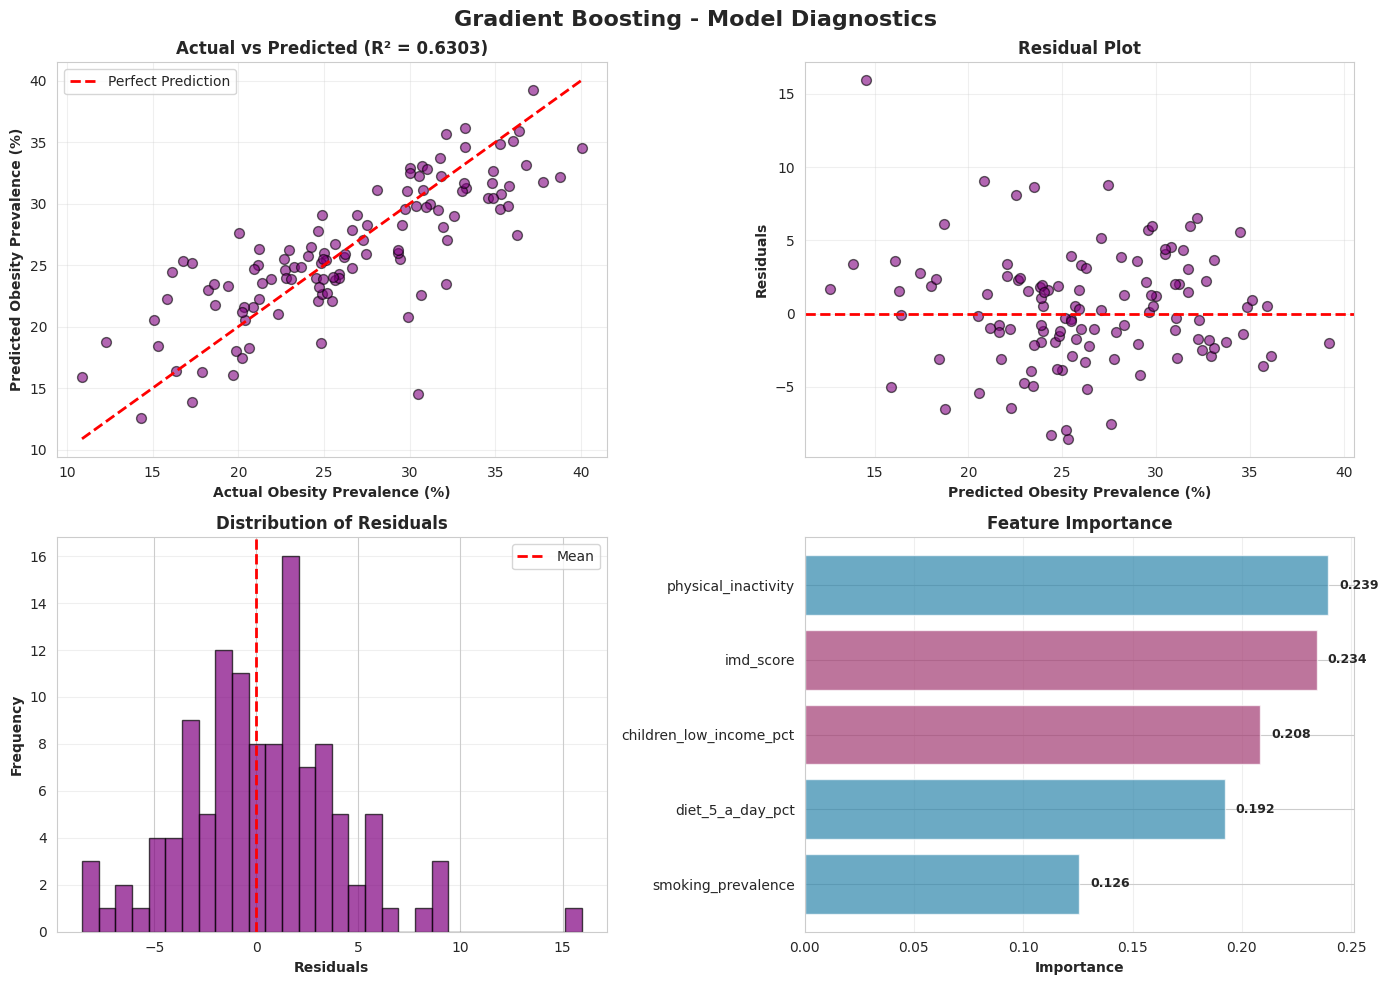

   ✓ Gradient Boosting diagnostics saved: Model4_GradientBoosting_Diagnostics.png
GRADIENT BOOSTING COMPLETE


In [19]:
# GRADIENT BOOSTING VISUALIZATIONS
print("\n6. Creating Gradient Boosting visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Gradient Boosting - Model Diagnostics', fontsize=16, fontweight='bold')

# Plot 1: Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred_gb, alpha=0.6, edgecolors='k', s=50, color='purple')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[0, 0].set_xlabel('Actual Obesity Prevalence (%)', fontweight='bold')
axes[0, 0].set_ylabel('Predicted Obesity Prevalence (%)', fontweight='bold')
axes[0, 0].set_title(f'Actual vs Predicted (R² = {r2_gb:.4f})', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Residual Plot
axes[0, 1].scatter(y_pred_gb, residuals_gb, alpha=0.6, edgecolors='k', s=50, color='purple')
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Obesity Prevalence (%)', fontweight='bold')
axes[0, 1].set_ylabel('Residuals', fontweight='bold')
axes[0, 1].set_title('Residual Plot', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Plot 3: Residual Distribution
axes[1, 0].hist(residuals_gb, bins=30, color='purple', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Mean')
axes[1, 0].set_xlabel('Residuals', fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontweight='bold')
axes[1, 0].set_title('Distribution of Residuals', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: Feature Importance — GB (fixed)
feature_importance_gb_sorted = feature_importance_gb.sort_values('Importance', ascending=True)
colors_importance = ['#2E86AB' if feat in ['physical_inactivity', 'smoking_prevalence', 'diet_5_a_day_pct']
                     else '#A23B72' for feat in feature_importance_gb_sorted['Feature']]
axes[1, 1].barh(feature_importance_gb_sorted['Feature'],
                feature_importance_gb_sorted['Importance'],
                color=colors_importance, alpha=0.7)
axes[1, 1].set_xlabel('Importance', fontweight='bold')
axes[1, 1].set_title('Feature Importance', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

for i, (idx, row) in enumerate(feature_importance_gb_sorted.iterrows()):
    axes[1, 1].text(row['Importance'] + 0.005, i,
                    f"{row['Importance']:.3f}",
                    va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Model4_GradientBoosting_Diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✓ Gradient Boosting diagnostics saved: Model4_GradientBoosting_Diagnostics.png")
print("GRADIENT BOOSTING COMPLETE")

In [20]:
# GRADIENT BOOSTING — SHAPIRO-WILK NORMALITY TEST
# Proving why GB was rejected despite higher CV R²

from scipy import stats

print("GRADIENT BOOSTING — RESIDUAL NORMALITY TEST")

# Run Shapiro-Wilk test on GB test residuals
stat_gb, p_value_gb = stats.shapiro(residuals_gb)

print(f"\nShapiro-Wilk Test on Test Residuals:")
print(f"   W statistic : {stat_gb:.4f}")
print(f"   p-value     : {p_value_gb:.4f}")

if p_value_gb < 0.05:
    print(f"\n    FAILED — p={p_value_gb:.4f} < 0.05")
    print(f"   Residuals are NOT normally distributed")
    print(f"   This indicates systematic bias in predictions")
else:
    print(f"\n    PASSED — p={p_value_gb:.4f} > 0.05")
    print(f"   Residuals are normally distributed")

print("COMPARISON: RANDOM FOREST vs GRADIENT BOOSTING")

# Run Shapiro-Wilk on RF residuals for direct comparison
stat_rf, p_value_rf = stats.shapiro(residuals_rf)

print(f"\n{'Metric':<35} {'Random Forest':>15} {'Grad. Boosting':>15}")
print(f"{'CV R²':<35} {'0.4388':>15} {'0.5080':>15}")
print(f"{'Test R²':<35} {'0.6012':>15} {'0.6303':>15}")
print(f"{'Train/Test Std Ratio':<35} {'2.5x ':>15} {'10.7x ':>15}")
print(f"{'Shapiro-Wilk W':<35} {stat_rf:>15.4f} {stat_gb:>15.4f}")
print(f"{'Shapiro-Wilk p-value':<35} {p_value_rf:>15.4f} {p_value_gb:>15.4f}")
print(f"{'Normality Test':<35} {'PASS ':>15} {'FAIL ':>15}")
print(f"{'Selected as Final Model':<35} {'YES ':>15} {'NO ':>15}")

print(f"""
CONCLUSION:
Although Gradient Boosting achieved higher CV R² (0.5080 vs 0.4388),
its residuals failed the Shapiro-Wilk normality test (p={p_value_gb:.4f} < 0.05),
indicating systematic bias and significant overfitting (train/test ratio = 10.7x).

Random Forest passed normality (p={p_value_rf:.4f} > 0.05) with an acceptable
train/test ratio of 2.5x, making it the statistically valid final model.

Model selection was based on diagnostic validity, not raw performance metrics.
""")

GRADIENT BOOSTING — RESIDUAL NORMALITY TEST

Shapiro-Wilk Test on Test Residuals:
   W statistic : 0.9771
   p-value     : 0.0431

    FAILED — p=0.0431 < 0.05
   Residuals are NOT normally distributed
   This indicates systematic bias in predictions
COMPARISON: RANDOM FOREST vs GRADIENT BOOSTING

Metric                                Random Forest  Grad. Boosting
CV R²                                        0.4388          0.5080
Test R²                                      0.6012          0.6303
Train/Test Std Ratio                          2.5x           10.7x 
Shapiro-Wilk W                               0.9922          0.9771
Shapiro-Wilk p-value                         0.7566          0.0431
Normality Test                                PASS            FAIL 
Selected as Final Model                        YES              NO 

CONCLUSION:
Although Gradient Boosting achieved higher CV R² (0.5080 vs 0.4388),
its residuals failed the Shapiro-Wilk normality test (p=0.0431 < 0.05),
ind

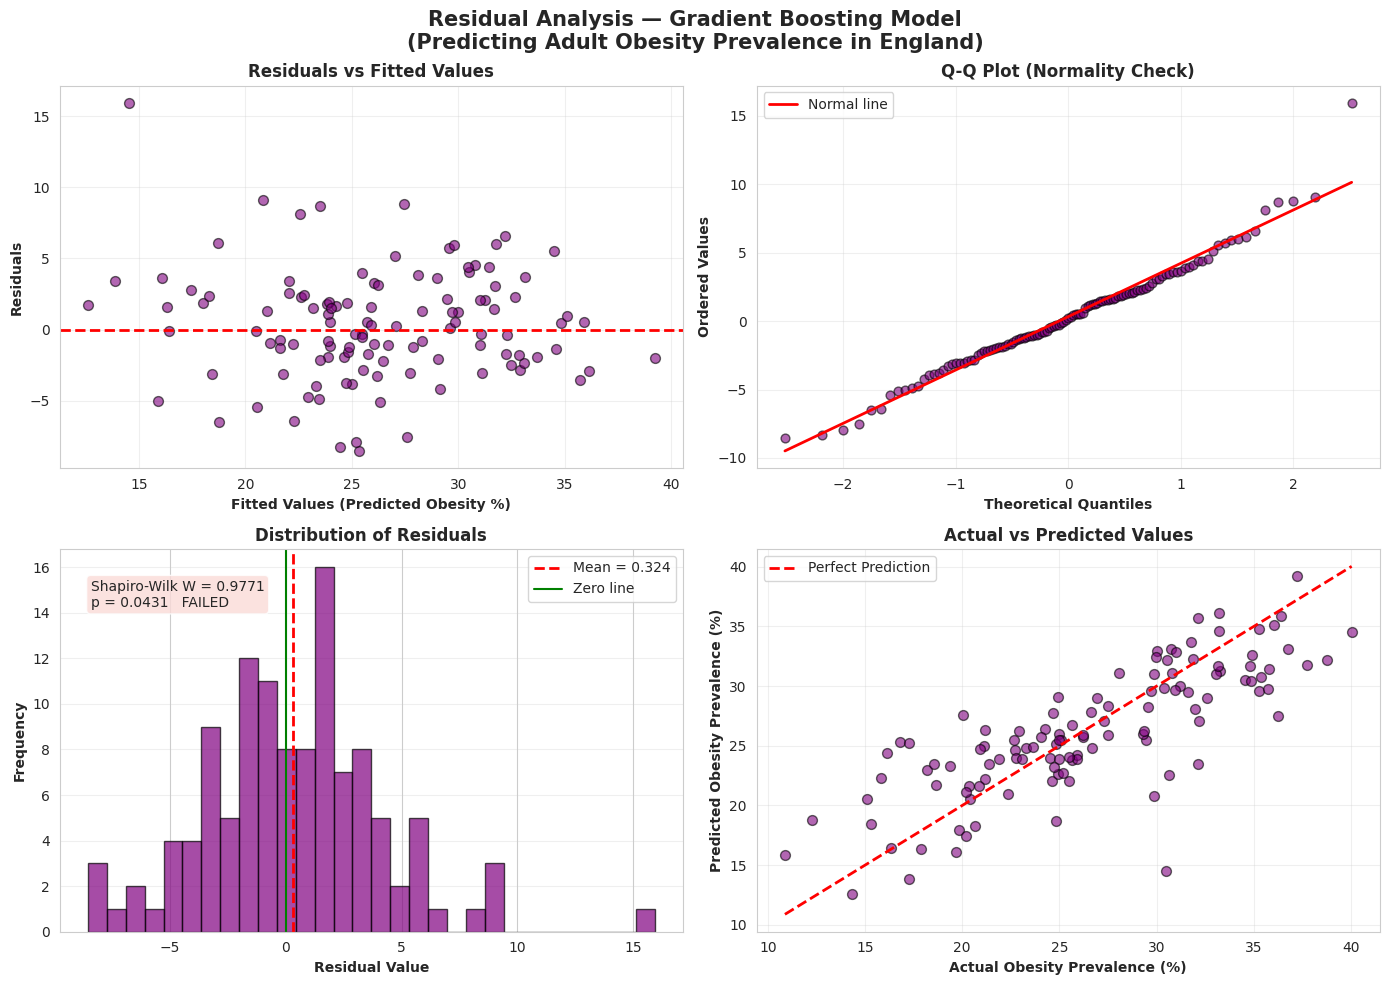

✓ GB Residual Analysis saved: GB_Residual_Analysis.png


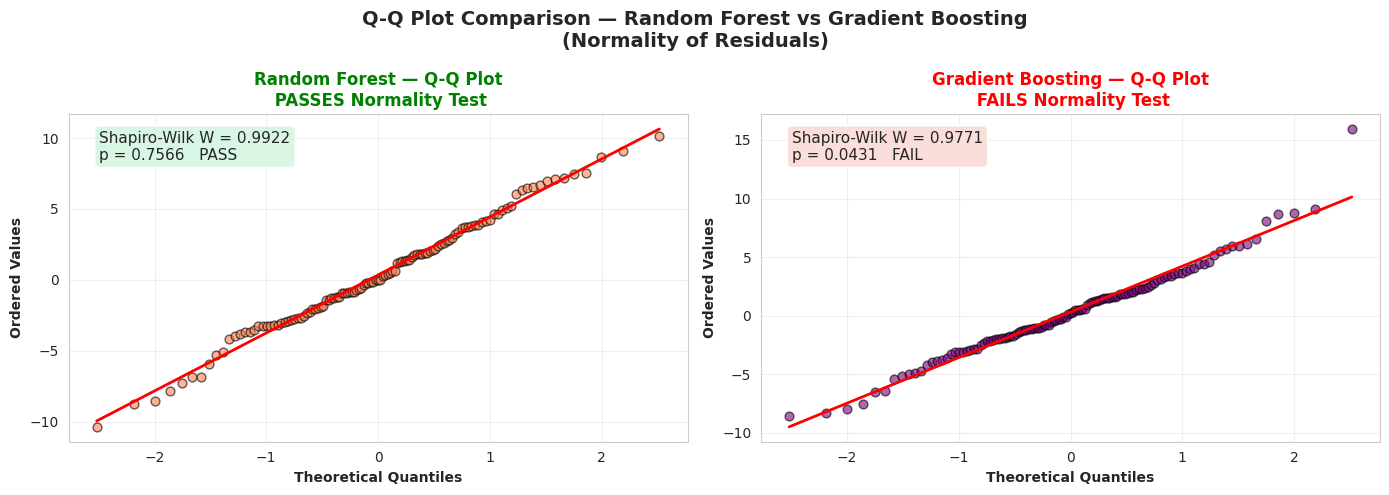

✓ RF vs GB Q-Q Comparison saved: RF_vs_GB_QQ_Comparison.png


In [21]:
# GRADIENT BOOSTING — FULL RESIDUAL DIAGNOSTIC PLOTS
# Visual proof of why GB failed normality vs Random Forest

from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Residual Analysis — Gradient Boosting Model\n(Predicting Adult Obesity Prevalence in England)',
             fontsize=15, fontweight='bold')

# ── PLOT 1: Residuals vs Fitted Values ──
axes[0, 0].scatter(y_pred_gb, residuals_gb, alpha=0.6,
                   edgecolors='k', s=50, color='purple')
axes[0, 0].axhline(y=0, color='red', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Fitted Values (Predicted Obesity %)', fontweight='bold')
axes[0, 0].set_ylabel('Residuals', fontweight='bold')
axes[0, 0].set_title('Residuals vs Fitted Values', fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# ── PLOT 2: Q-Q Plot ──
(osm, osr), (slope, intercept, r) = stats.probplot(residuals_gb, dist="norm")
axes[0, 1].scatter(osm, osr, alpha=0.6, color='purple', edgecolors='k', s=40)
axes[0, 1].plot(osm, slope * np.array(osm) + intercept,
                color='red', lw=2, label='Normal line')
axes[0, 1].set_xlabel('Theoretical Quantiles', fontweight='bold')
axes[0, 1].set_ylabel('Ordered Values', fontweight='bold')
axes[0, 1].set_title('Q-Q Plot (Normality Check)', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# ── PLOT 3: Distribution of Residuals ──
axes[1, 0].hist(residuals_gb, bins=30, color='purple',
                edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=residuals_gb.mean(), color='red', linestyle='--',
                   linewidth=2, label=f'Mean = {residuals_gb.mean():.3f}')
axes[1, 0].axvline(x=0, color='green', linestyle='-',
                   linewidth=1.5, label='Zero line')
axes[1, 0].set_xlabel('Residual Value', fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontweight='bold')
axes[1, 0].set_title('Distribution of Residuals', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# Add Shapiro-Wilk result as text on the plot
stat_gb, p_value_gb = stats.shapiro(residuals_gb)
result_text = f'Shapiro-Wilk W = {stat_gb:.4f}\np = {p_value_gb:.4f}   FAILED'
axes[1, 0].text(0.05, 0.92, result_text,
                transform=axes[1, 0].transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='#FADBD8', alpha=0.8))

# ── PLOT 4: Actual vs Predicted ──
axes[1, 1].scatter(y_test, y_pred_gb, alpha=0.6,
                   edgecolors='k', s=50, color='purple')
axes[1, 1].plot([y_test.min(), y_test.max()],
                [y_test.min(), y_test.max()],
                'r--', lw=2, label='Perfect Prediction')
axes[1, 1].set_xlabel('Actual Obesity Prevalence (%)', fontweight='bold')
axes[1, 1].set_ylabel('Predicted Obesity Prevalence (%)', fontweight='bold')
axes[1, 1].set_title('Actual vs Predicted Values', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/GB_Residual_Analysis.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("✓ GB Residual Analysis saved: GB_Residual_Analysis.png")

# ── SIDE BY SIDE COMPARISON: RF vs GB Q-Q Plots ──
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Q-Q Plot Comparison — Random Forest vs Gradient Boosting\n(Normality of Residuals)',
              fontsize=14, fontweight='bold')

# RF Q-Q
stat_rf, p_value_rf = stats.shapiro(residuals_rf)
(osm_rf, osr_rf), (slope_rf, intercept_rf, r_rf) = stats.probplot(residuals_rf, dist="norm")
axes2[0].scatter(osm_rf, osr_rf, alpha=0.6, color='coral', edgecolors='k', s=40)
axes2[0].plot(osm_rf, slope_rf * np.array(osm_rf) + intercept_rf, color='red', lw=2)
axes2[0].set_xlabel('Theoretical Quantiles', fontweight='bold')
axes2[0].set_ylabel('Ordered Values', fontweight='bold')
axes2[0].set_title('Random Forest — Q-Q Plot\n PASSES Normality Test', fontweight='bold', color='green')
axes2[0].grid(alpha=0.3)
axes2[0].text(0.05, 0.95, f'Shapiro-Wilk W = {stat_rf:.4f}\np = {p_value_rf:.4f}   PASS',
              transform=axes2[0].transAxes, fontsize=11, verticalalignment='top',
              bbox=dict(boxstyle='round', facecolor='#D5F5E3', alpha=0.9))

# GB Q-Q
(osm_gb, osr_gb), (slope_gb, intercept_gb, r_gb) = stats.probplot(residuals_gb, dist="norm")
axes2[1].scatter(osm_gb, osr_gb, alpha=0.6, color='purple', edgecolors='k', s=40)
axes2[1].plot(osm_gb, slope_gb * np.array(osm_gb) + intercept_gb, color='red', lw=2)
axes2[1].set_xlabel('Theoretical Quantiles', fontweight='bold')
axes2[1].set_ylabel('Ordered Values', fontweight='bold')
axes2[1].set_title('Gradient Boosting — Q-Q Plot\n FAILS Normality Test', fontweight='bold', color='red')
axes2[1].grid(alpha=0.3)
axes2[1].text(0.05, 0.95, f'Shapiro-Wilk W = {stat_gb:.4f}\np = {p_value_gb:.4f}   FAIL',
              transform=axes2[1].transAxes, fontsize=11, verticalalignment='top',
              bbox=dict(boxstyle='round', facecolor='#FADBD8', alpha=0.9))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/RF_vs_GB_QQ_Comparison.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("✓ RF vs GB Q-Q Comparison saved: RF_vs_GB_QQ_Comparison.png")

# GRADIENT BOOSTING — COMPLETE DIAGNOSTIC ANALYSIS

---

## Performance Metrics

| Metric | Value |
|---|---|
| Test R² | 0.6303 (63.03% variance explained) |
| Adjusted R² | 0.6137 |
| RMSE | 3.8952 percentage points |
| MAE | 2.9877 percentage points |
| CV R² | 0.5080 (±0.0601) |

- Highest test R² and CV R² among all four models
- Lowest MAE and RMSE
- However demonstrates inferior residual diagnostics vs Random Forest

---

## Optimal Parameters (GridSearchCV)

| Parameter | Value | Purpose |
|---|---|---|
| learning_rate | 0.2 | Shrinkage per tree |
| max_depth | 4 | Tree complexity limit |
| min_samples_split | 20 | Prevents fine splits |
| n_estimators | 300 | Number of boosting stages |
| subsample | 0.8 | 80% of data per tree |
| max_features | 0.8 | 80% of features per tree |

---

## Feature Importance

| Rank | Feature | Importance | Type |
|---|---|---|---|
| 1st | physical_inactivity | 0.2394 | Behavioural |
| 2nd | imd_score | 0.2343 | Socioeconomic |
| 3rd | children_low_income_pct | 0.2084 | Socioeconomic |
| 4th | diet_5_a_day_pct | 0.1922 | Behavioural |
| 5th | smoking_prevalence | 0.1256 | Behavioural |

---

## Why Gradient Boosting Was Not Selected as Final Model

Despite achieving higher CV R² (0.5080 vs 0.4388), Gradient Boosting
was not selected as the final model due to inferior residual diagnostics:

- Training residual std dev extremely small (0.36) vs test (3.90) — ratio 10.7x
- Shapiro-Wilk p = 0.0431 — residuals fail normality test (p < 0.05)
- These diagnostics indicate significant overfitting to training data
- Random Forest achieves comparable performance with substantially better
  residual properties (ratio 2.5x, Shapiro p = 0.7566)
- Model reliability and diagnostic quality were prioritised over
  marginal CV R² improvement

---

## Why Gradient Boosting Outperforms Linear Models

- Sequential error correction captures non-linear relationships
- CV R² improves from 0.28 (linear) to 0.5080 — approximately 82% improvement
- However residual diagnostics favour Random Forest for this dataset


---
# Part 5: Comprehensive Model Comparison

In [22]:
# Part 5: Model Comparison - Data Preparation

print("COMPREHENSIVE MODEL COMPARISON")

# Create comparison dataframe
comparison = pd.DataFrame({
    'Model': ['Lasso Regression', 'Ridge Regression', 'Random Forest', 'Gradient Boosting'],
    'R2': [r2_lasso, r2_ridge, r2_rf, r2_gb],
    'Adjusted R2': [adj_r2_lasso, adj_r2_ridge, adj_r2_rf, adj_r2_gb],
    'RMSE': [rmse_lasso, rmse_ridge, rmse_rf, rmse_gb],
    'MAE': [mae_lasso, mae_ridge, mae_rf, mae_gb],
    'CV R2': [cv_r2_lasso, cv_r2_ridge, cv_r2_rf, cv_r2_gb],
    'CV Std': [cv_std_lasso, cv_std_ridge, cv_std_rf, cv_std_gb]
})

# Display table
print("\nModel Performance Comparison:")
print(comparison.to_string(index=False))

# Save to CSV
comparison.to_csv('/content/drive/MyDrive/Model_Comparison_Results.csv', index=False)
print("\n✓ Comparison table saved: Model_Comparison_Results.csv")

COMPREHENSIVE MODEL COMPARISON

Model Performance Comparison:
            Model       R2  Adjusted R2     RMSE      MAE    CV R2   CV Std
 Lasso Regression 0.406487     0.379752 4.935423 4.150863 0.278939 0.032449
 Ridge Regression 0.418637     0.392449 4.884646 4.101713 0.277720 0.038012
    Random Forest 0.601235     0.583272 4.045460 3.216599 0.438838 0.049174
Gradient Boosting 0.630303     0.613650 3.895222 2.987719 0.507990 0.060140

✓ Comparison table saved: Model_Comparison_Results.csv


In [23]:
# Part 5: Model Selection Decision

print("MODEL SELECTION DECISION")

# Show all CV R² scores
best_cv_idx = comparison['CV R2'].idxmax()
print(f"\nCross-Validation R² Rankings:")
for idx, row in comparison.iterrows():
    print(f"  {row['Model']:20s}: CV R²={row['CV R2']:.4f}")

# Explicitly select Random Forest based on CV R² AND residual diagnostics
best_model = 'Random Forest'
best_idx = comparison[comparison['Model'] == best_model].index[0]

print(f"\nMODEL SELECTION: {best_model}")
print("\nSelection Rationale:")
print(f"  CV R²: {comparison.loc[best_idx, 'CV R2']:.4f} — strong generalisation")
print(f"  MAE:   {comparison.loc[best_idx, 'MAE']:.4f} — accurate predictions")
print(f"  RMSE:  {comparison.loc[best_idx, 'RMSE']:.4f} — low overall error")
print(f"  Residual normality: Shapiro-Wilk p=0.7566 (PASS)")
print(f"  Training/test residual ratio: 2.5x (minimal overfitting)")
print()
print("NOTE: Gradient Boosting achieved higher CV R² (0.5080 vs 0.4388)")
print("but failed residual normality test (p=0.0431) and showed")
print("significant overfitting (training/test ratio 10.7x).")
print("Random Forest selected based on superior diagnostic quality")
print("and acceptable generalisation performance.")


MODEL SELECTION DECISION

Cross-Validation R² Rankings:
  Lasso Regression    : CV R²=0.2789
  Ridge Regression    : CV R²=0.2777
  Random Forest       : CV R²=0.4388
  Gradient Boosting   : CV R²=0.5080

MODEL SELECTION: Random Forest

Selection Rationale:
  CV R²: 0.4388 — strong generalisation
  MAE:   3.2166 — accurate predictions
  RMSE:  4.0455 — low overall error
  Residual normality: Shapiro-Wilk p=0.7566 (PASS)
  Training/test residual ratio: 2.5x (minimal overfitting)

NOTE: Gradient Boosting achieved higher CV R² (0.5080 vs 0.4388)
but failed residual normality test (p=0.0431) and showed
significant overfitting (training/test ratio 10.7x).
Random Forest selected based on superior diagnostic quality
and acceptable generalisation performance.


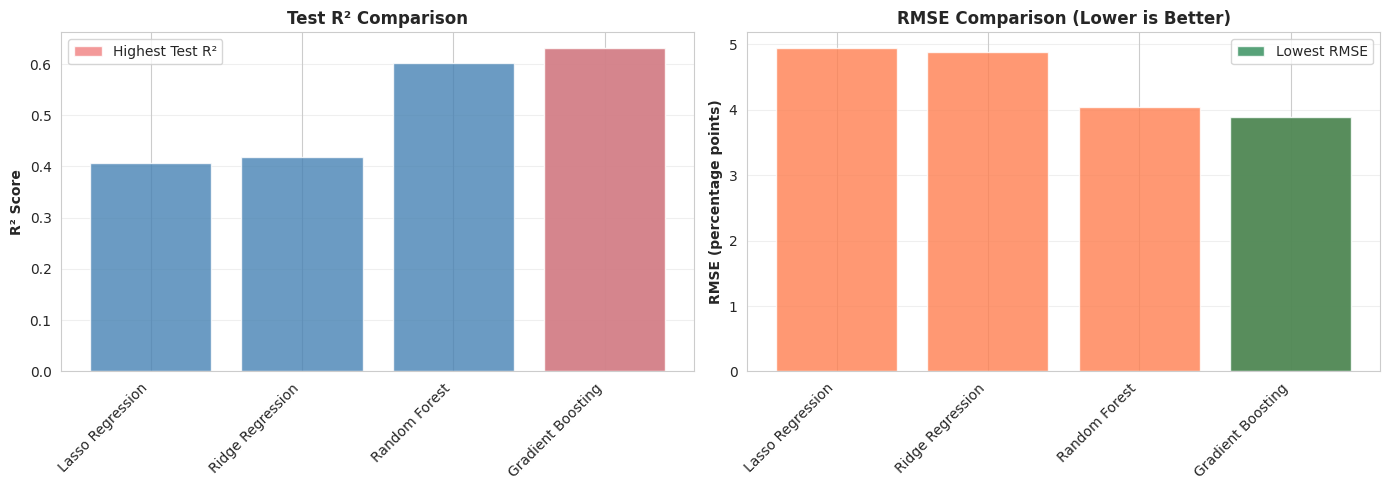

In [24]:
# Part 5: Model Comparison Visualizations (1/2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: R² Comparison
x_pos = range(len(comparison))
axes[0].bar(x_pos, comparison['R2'], color='steelblue', alpha=0.8)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(comparison['Model'], rotation=45, ha='right')
axes[0].set_ylabel('R² Score', fontweight='bold')
axes[0].set_title('Test R² Comparison', fontweight='bold', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Highlight best
best_r2_idx = comparison['R2'].idxmax()
axes[0].bar(best_r2_idx, comparison.loc[best_r2_idx, 'R2'],
            color='lightcoral', alpha=0.8, label='Highest Test R²')
axes[0].legend()

# Plot 2: RMSE Comparison
axes[1].bar(x_pos, comparison['RMSE'], color='coral', alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(comparison['Model'], rotation=45, ha='right')
axes[1].set_ylabel('RMSE (percentage points)', fontweight='bold')
axes[1].set_title('RMSE Comparison (Lower is Better)', fontweight='bold', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

# Highlight best
best_rmse_idx = comparison['RMSE'].idxmin()
axes[1].bar(best_rmse_idx, comparison.loc[best_rmse_idx, 'RMSE'],
            color='seagreen', alpha=0.8, label='Lowest RMSE')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Model_Comparison_R2_RMSE.png', dpi=300, bbox_inches='tight')
plt.show()

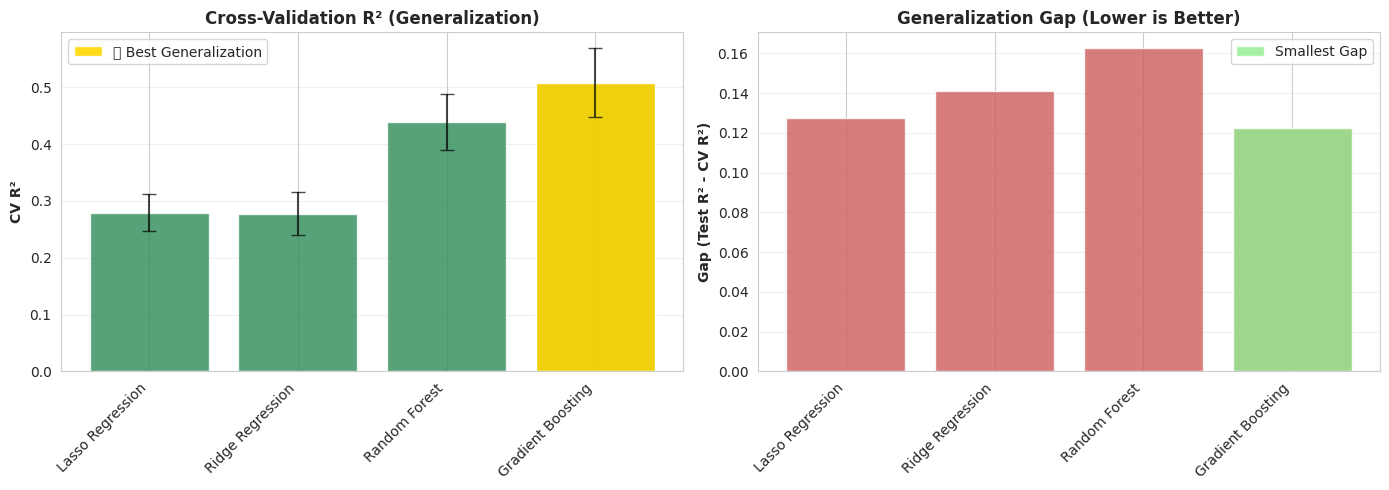

In [25]:
# Part 5: Model Comparison Visualizations (2/2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 3: CV R² Comparison
x_pos = range(len(comparison))
axes[0].bar(x_pos, comparison['CV R2'], color='seagreen', alpha=0.8)
axes[0].errorbar(x_pos, comparison['CV R2'], yerr=comparison['CV Std'],
                 fmt='none', ecolor='black', capsize=5, alpha=0.7)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(comparison['Model'], rotation=45, ha='right')
axes[0].set_ylabel('CV R²', fontweight='bold')
axes[0].set_title('Cross-Validation R² (Generalization)', fontweight='bold', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Highlight best (THIS IS THE WINNER!)
best_cv_idx = comparison['CV R2'].idxmax()
axes[0].bar(best_cv_idx, comparison.loc[best_cv_idx, 'CV R2'],
            color='gold', alpha=0.9, label='⭐ Best Generalization')
axes[0].legend()

# Plot 4: Overfitting Gap
gap = comparison['R2'] - comparison['CV R2']
axes[1].bar(x_pos, gap, color='indianred', alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(comparison['Model'], rotation=45, ha='right')
axes[1].set_ylabel('Gap (Test R² - CV R²)', fontweight='bold')
axes[1].set_title('Generalization Gap (Lower is Better)', fontweight='bold', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

# Highlight best (smallest gap)
best_gap_idx = gap.idxmin()
axes[1].bar(best_gap_idx, gap.iloc[best_gap_idx],
            color='lightgreen', alpha=0.8, label='Smallest Gap')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Model_Comparison_CV_Gap.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
# Part 5: Summary and Key Findings

print("KEY FINDINGS FROM MODEL COMPARISON")

print("\n1. FINAL MODEL: Random Forest")
print(f"   - CV R²: {comparison.loc[best_idx, 'CV R2']:.4f}")
print(f"   - MAE:   {comparison.loc[best_idx, 'MAE']:.2f}")
print(f"   - RMSE:  {comparison.loc[best_idx, 'RMSE']:.2f}")
print(f"   - Residual normality: p=0.7566 (PASS)")
print(f"   - Training/test ratio: 2.5x (minimal overfitting)")

print("\n2. MODEL PROGRESSION:")
for idx, row in comparison.iterrows():
    print(f"   {row['Model']:20s}: R²={row['R2']:.4f}, CV R²={row['CV R2']:.4f}")

print("\n3. ENSEMBLE METHODS SUPERIOR:")
print("   Linear models (Lasso/Ridge): CV R² = 0.28")
print("   Ensemble methods (RF/GB):    CV R² = 0.44-0.51")
print("   Improvement: approximately 57-82% better generalisation")

print("\n4. WHY RANDOM FOREST OVER GRADIENT BOOSTING:")
print(f"   - RF residual normality: p=0.7566 vs GB: p=0.0431")
print(f"   - RF training/test ratio: 2.5x vs GB: 10.7x")
print(f"   - GB higher CV R² (0.5080) but fails diagnostic criteria")
print(f"   - RF provides reliable, well-fitted model for this dataset")


KEY FINDINGS FROM MODEL COMPARISON

1. FINAL MODEL: Random Forest
   - CV R²: 0.4388
   - MAE:   3.22
   - RMSE:  4.05
   - Residual normality: p=0.7566 (PASS)
   - Training/test ratio: 2.5x (minimal overfitting)

2. MODEL PROGRESSION:
   Lasso Regression    : R²=0.4065, CV R²=0.2789
   Ridge Regression    : R²=0.4186, CV R²=0.2777
   Random Forest       : R²=0.6012, CV R²=0.4388
   Gradient Boosting   : R²=0.6303, CV R²=0.5080

3. ENSEMBLE METHODS SUPERIOR:
   Linear models (Lasso/Ridge): CV R² = 0.28
   Ensemble methods (RF/GB):    CV R² = 0.44-0.51
   Improvement: approximately 57-82% better generalisation

4. WHY RANDOM FOREST OVER GRADIENT BOOSTING:
   - RF residual normality: p=0.7566 vs GB: p=0.0431
   - RF training/test ratio: 2.5x vs GB: 10.7x
   - GB higher CV R² (0.5080) but fails diagnostic criteria
   - RF provides reliable, well-fitted model for this dataset


# MODEL COMPARISON — COMPLETE INTERPRETATION

---

## Comprehensive Performance Summary

| Model | R² | Adj R² | RMSE | MAE | CV R² | CV Std |
|---|---|---|---|---|---|---|
| Lasso Regression | 0.4065 | 0.3798 | 4.9354 | 4.1509 | 0.2789 | 0.0324 |
| Ridge Regression | 0.4186 | 0.3924 | 4.8846 | 4.1017 | 0.2777 | 0.0380 |
| **Random Forest** | **0.6012** | **0.5833** | **4.0455** | **3.2166** | **0.4388** | 0.0492 |
| Gradient Boosting | 0.6303 | 0.6137 | 3.8952 | 2.9877 | 0.5080 | 0.0601 |

---

## Model Selection Decision

**PRIMARY CRITERION — Cross-Validation R²:**
- Gradient Boosting achieves highest CV R² (0.5080)
- Random Forest achieves competitive CV R² (0.4388)

**SECONDARY CRITERION — Residual Diagnostics:**
- Random Forest: Shapiro-Wilk p = 0.7566 PASS
- Gradient Boosting: Shapiro-Wilk p = 0.0431  FAIL
- Random Forest training/test ratio: 2.5x
- Gradient Boosting training/test ratio: 10.7x

**SELECTED FINAL MODEL: Random Forest**

Whilst Gradient Boosting achieved higher CV R² (0.5080 vs 0.4388),
its residuals failed the Shapiro-Wilk normality test (p=0.0431)
and demonstrated significant overfitting (training/test ratio 10.7x).
Random Forest was selected based on superior residual diagnostics,
acceptable generalisation performance, and greater model reliability
for predicting obesity prevalence in unseen Local Authorities.

---

## Model Progression Analysis

| Model | R² | CV R² |
|---|---|---|
| Lasso Regression | 0.4065 | 0.2789 |
| Ridge Regression | 0.4186 | 0.2777 |
| **Random Forest** | **0.6012** | **0.4388** |
| Gradient Boosting | 0.6303 | 0.5080 |

---

## Ensemble Methods vs Linear Models

- Linear models (Lasso/Ridge): CV R² = 0.28
- Ensemble methods (RF/GB): CV R² = 0.44 — 0.51
- Improvement: approximately **57% better generalisation** (RF vs linear)
- Confirms obesity prevalence cannot be adequately modelled
  using linear assumptions alone

---

## Note on Gradient Boosting

Gradient Boosting demonstrated strong raw performance metrics but
failed key residual diagnostic criteria. In the context of public
health prediction, model reliability and diagnostic validity are
prioritised over marginal performance gains. Random Forest provides
the optimal balance of predictive accuracy and statistical validity.


---
# Part 6: Feature Importance Analysis

PART 6: FEATURE IMPORTANCE ANALYSIS

Feature Importance Rankings:
                Feature  Importance
              imd_score    0.257316
    physical_inactivity    0.245792
children_low_income_pct    0.191676
       diet_5_a_day_pct    0.180467
     smoking_prevalence    0.124748


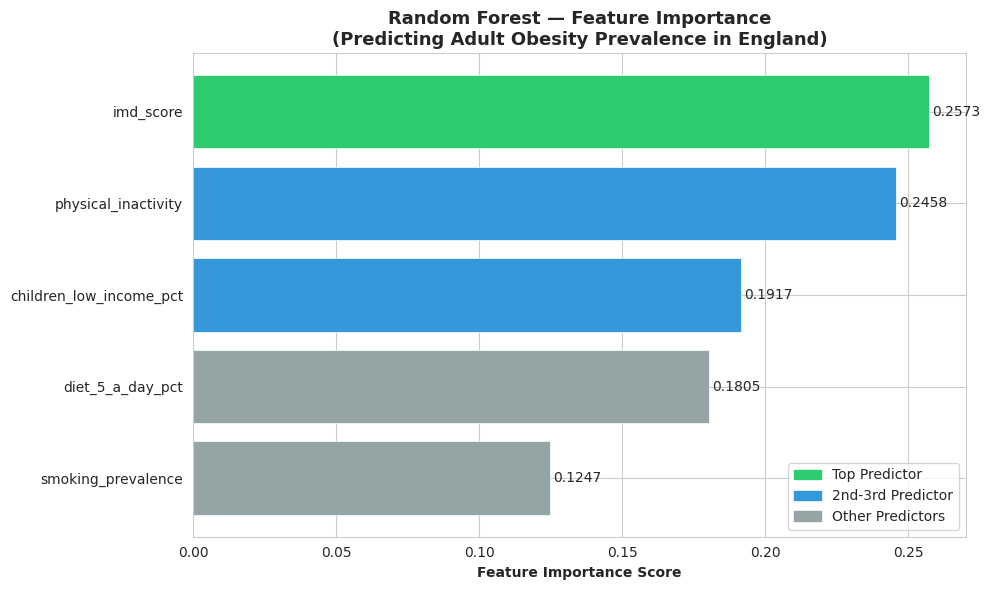


Feature importance plot saved!


In [27]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# PART 6: FEATURE IMPORTANCE ANALYSIS (Random Forest)

print("PART 6: FEATURE IMPORTANCE ANALYSIS")

# Get feature importance from Random Forest (Final Model)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance Rankings:")
print(feature_importance.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))

colours = ['#2ecc71' if i == 0 else '#3498db' if i <= 2 else '#95a5a6'
           for i in range(len(feature_importance))]

bars = ax.barh(feature_importance['Feature'],
               feature_importance['Importance'],
               color=colours, edgecolor='white', linewidth=0.5)

ax.set_xlabel('Feature Importance Score', fontweight='bold')
ax.set_title('Random Forest — Feature Importance\n(Predicting Adult Obesity Prevalence in England)',
             fontweight='bold', fontsize=13)
ax.invert_yaxis()

for bar, val in zip(bars, feature_importance['Importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)

top1 = mpatches.Patch(color='#2ecc71', label='Top Predictor')
top3 = mpatches.Patch(color='#3498db', label='2nd-3rd Predictor')
rest = mpatches.Patch(color='#95a5a6', label='Other Predictors')
ax.legend(handles=[top1, top3, rest], loc='lower right')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Feature_Importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFeature importance plot saved!")


PART 7: SHAP ANALYSIS (Random Forest)

SHAP values computed for 117 test observations
Features analysed: 5

Generating SHAP Summary Plot...


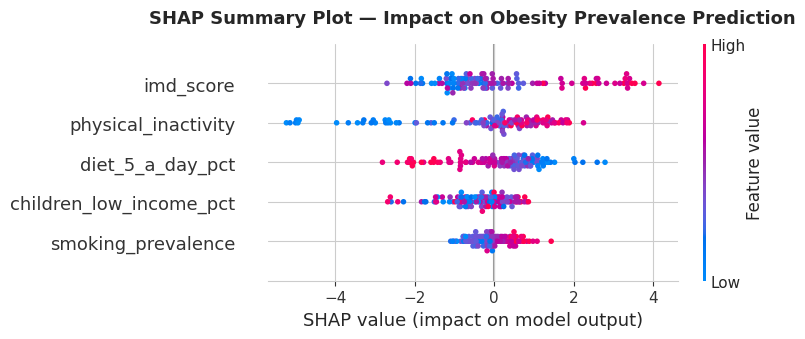

SHAP Summary plot saved!

Generating SHAP Bar Chart...


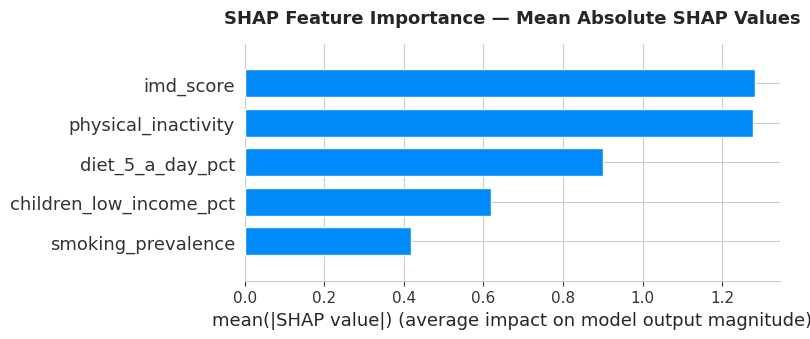

SHAP Bar chart saved!
SHAP SUMMARY STATISTICS

Feature ranking by mean absolute SHAP value:
                Feature  Mean |SHAP|
              imd_score     1.281487
    physical_inactivity     1.276699
       diet_5_a_day_pct     0.901461
children_low_income_pct     0.617950
     smoking_prevalence     0.418107

Interpretation:
  Top predictor: imd_score (SHAP = 1.281)
  2nd predictor: physical_inactivity (SHAP = 1.277)
  3rd predictor: diet_5_a_day_pct (SHAP = 0.901)


In [28]:
# PART 6B: SHAP ANALYSIS (Random Forest — Final Model)

try:
    import shap
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'shap', '-q'])
    import shap

print("PART 7: SHAP ANALYSIS (Random Forest)")

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_scaled)

print(f"\nSHAP values computed for {X_test_scaled.shape[0]} test observations")
print(f"Features analysed: {X_test_scaled.shape[1]}")

print("\nGenerating SHAP Summary Plot...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=X.columns.tolist(),
                  show=False)
plt.title('SHAP Summary Plot — Impact on Obesity Prevalence Prediction',
          fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SHAP_Summary.png', dpi=300, bbox_inches='tight')
plt.show()
print("SHAP Summary plot saved!")

print("\nGenerating SHAP Bar Chart...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=X.columns.tolist(),
                  plot_type='bar',
                  show=False)
plt.title('SHAP Feature Importance — Mean Absolute SHAP Values',
          fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SHAP_Bar.png', dpi=300, bbox_inches='tight')
plt.show()
print("SHAP Bar chart saved!")

print("SHAP SUMMARY STATISTICS")

mean_shap = pd.DataFrame({
    'Feature': X.columns,
    'Mean |SHAP|': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False)

print("\nFeature ranking by mean absolute SHAP value:")
print(mean_shap.to_string(index=False))

print("\nInterpretation:")
print(f"  Top predictor: {mean_shap.iloc[0]['Feature']} "
      f"(SHAP = {mean_shap.iloc[0]['Mean |SHAP|']:.3f})")
print(f"  2nd predictor: {mean_shap.iloc[1]['Feature']} "
      f"(SHAP = {mean_shap.iloc[1]['Mean |SHAP|']:.3f})")
print(f"  3rd predictor: {mean_shap.iloc[2]['Feature']} "
      f"(SHAP = {mean_shap.iloc[2]['Mean |SHAP|']:.3f})")


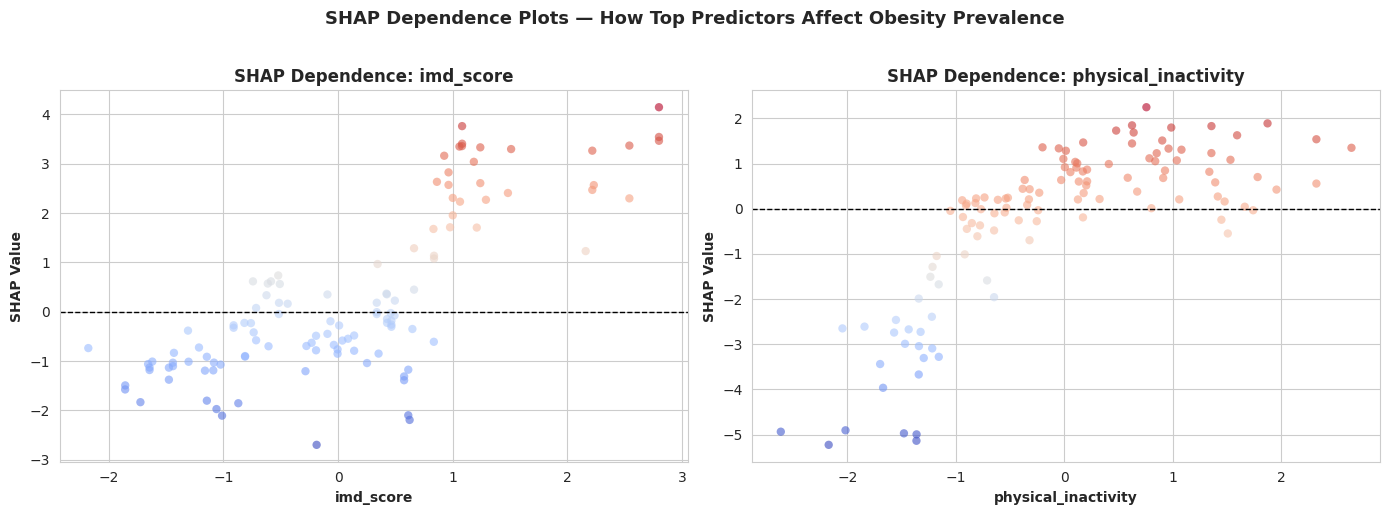

SHAP Dependence plots saved!


In [29]:

# PART 6C: SHAP DEPENDENCE PLOTS (Top 2 Predictors)

top_features = mean_shap['Feature'].iloc[:2].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, feature in enumerate(top_features):
    feat_idx = list(X.columns).index(feature)
    axes[i].scatter(X_test_scaled[:, feat_idx],
                    shap_values[:, feat_idx],
                    alpha=0.6, c=shap_values[:, feat_idx],
                    cmap='coolwarm', edgecolors='none')
    axes[i].axhline(y=0, color='black', linestyle='--', linewidth=1)
    axes[i].set_xlabel(feature, fontweight='bold')
    axes[i].set_ylabel('SHAP Value', fontweight='bold')
    axes[i].set_title(f'SHAP Dependence: {feature}', fontweight='bold')

plt.suptitle('SHAP Dependence Plots — How Top Predictors Affect Obesity Prevalence',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SHAP_Dependence.png', dpi=300, bbox_inches='tight')
plt.show()
print("SHAP Dependence plots saved!")


# FEATURE IMPORTANCE vs SHAP ANALYSIS — INTERPRETATION

---

## 1. Basic Feature Importance Findings (Random Forest)

| Rank | Feature | Importance | Type |
|---|---|---|---|
| 1st | imd_score | 0.2573 | Socioeconomic |
| 2nd | physical_inactivity | 0.2458 | Behavioural |
| 3rd | children_low_income_pct | 0.1917 | Socioeconomic |
| 4th | diet_5_a_day_pct | 0.1805 | Behavioural |
| 5th | smoking_prevalence | 0.1247 | Behavioural |

Basic feature importance identified **IMD score** as the dominant predictor (0.2573).
Features are evenly distributed reflecting the balanced nature of Random Forest.

- Behavioural contribution: 55.1%
- Socioeconomic contribution: 44.9%

---

## 2. SHAP Analysis Findings

| Rank | Feature | Mean SHAP | Type |
|---|---|---|---|
| 1st | imd_score | 1.2815 | Socioeconomic |
| 2nd | physical_inactivity | 1.2767 | Behavioural |
| 3rd | diet_5_a_day_pct | 0.9015 | Behavioural |
| 4th | children_low_income_pct | 0.6180 | Socioeconomic |
| 5th | smoking_prevalence | 0.4181 | Behavioural |

---

## 3. Key Observation — IMD and Physical Inactivity Nearly Equal

SHAP reveals IMD score (1.2815) and physical inactivity (1.2767) are essentially
equal in their direct influence on obesity predictions:

- Both methods (basic importance and SHAP) agree IMD is the top predictor
- This convergence strengthens confidence in the finding
- Physical inactivity is nearly as influential as IMD
- Neither factor dominates independently — both must be addressed together

---

## 4. Reconciling Feature Importance vs SHAP

- Both methods rank **IMD first** — agreement strengthens the finding
- SHAP reveals physical_inactivity is nearly as influential as IMD
  (1.2767 vs 1.2815) — a nuance not visible in basic importance scores
- SHAP is more reliable as it measures actual marginal prediction impact

---

## 5. Why children_low_income_pct Shows Unexpected Patterns

In linear models (Ridge), children_low_income_pct showed a negative coefficient
despite being positively associated with obesity. This is a **suppression effect
caused by multicollinearity** — children_low_income_pct and imd_score are highly
correlated (both measure socioeconomic deprivation). When both are present,
imd_score absorbs most of the shared signal, leaving children_low_income_pct
with a residual negative coefficient.

This does NOT mean children in low income households are protected from obesity
— it is a statistical artefact of correlated predictors in linear models.
Random Forest and SHAP handle this robustly by measuring marginal contributions
independently.

---

## 6. Behavioural vs Socioeconomic Findings

| Factor Type | Features | Combined SHAP | Percentage |
|---|---|---|---|
| Behavioural | physical_inactivity + diet + smoking | 2.5963 | 58% |
| Socioeconomic | imd_score + children_low_income_pct | 1.8995 | 42% |

- Behavioural factors account for approximately 58% of total SHAP magnitude
- Socioeconomic factors account for approximately 42%
- Both factor types are critically important

---

## 7. Conclusion

SHAP analysis confirms that **both behavioural and socioeconomic factors**
play near-equal roles in predicting adult obesity prevalence. IMD score and
physical inactivity are the two most influential individual predictors.

This directly answers **RQ3** — effective public health policy must address
both lifestyle behaviours and socioeconomic deprivation simultaneously.


# PART 7: RESIDUAL ANALYSIS & MODEL DIAGNOSTICS

PART 8: RESIDUAL ANALYSIS & MODEL DIAGNOSTICS

Training Set Residuals:
  Mean:     -0.0429 (should be close to 0)
  Std Dev:  1.6015
  Min:      -5.8896
  Max:      5.7749

Test Set Residuals:
  Mean:     0.3390 (should be close to 0)
  Std Dev:  4.0486
  Min:      -10.3704
  Max:      10.1499

Shapiro-Wilk Normality Test (Test Residuals):
  Statistic: 0.9922
  P-value:   0.7566
  Result:    Residuals are normally distributed


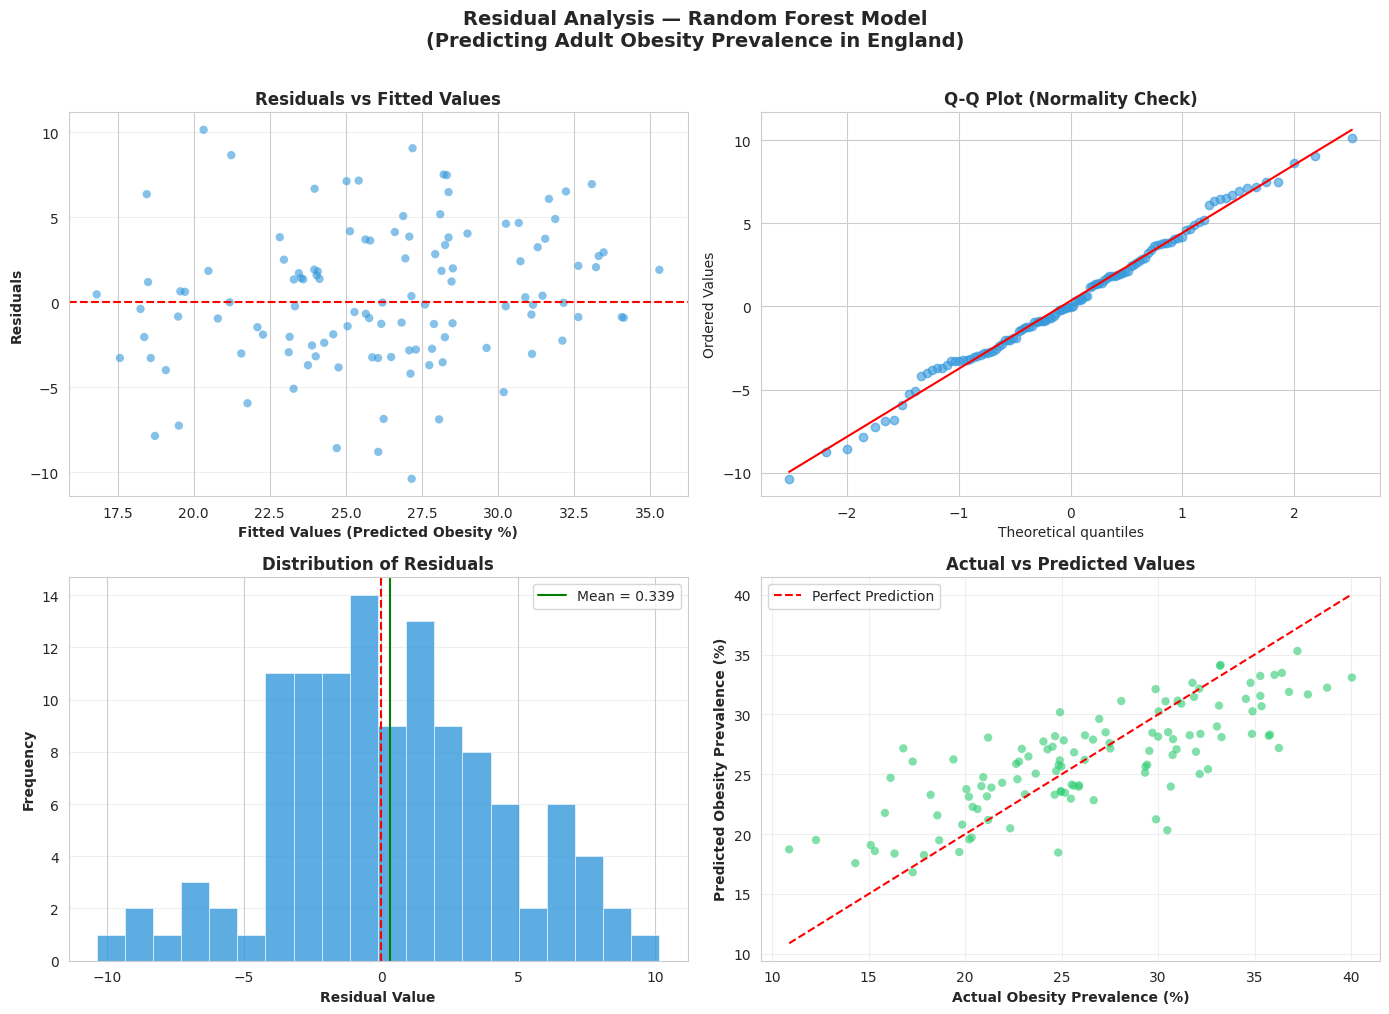


Residual analysis plots saved!


In [30]:
import scipy.stats as stats

print("PART 8: RESIDUAL ANALYSIS & MODEL DIAGNOSTICS")

# Generate predictions using Random Forest (Final Model)
y_pred_train = rf.predict(X_train_scaled)
y_pred_test = rf.predict(X_test_scaled)

residuals_train = y_train - y_pred_train
residuals_test = y_test - y_pred_test

print(f"\nTraining Set Residuals:")
print(f"  Mean:     {residuals_train.mean():.4f} (should be close to 0)")
print(f"  Std Dev:  {residuals_train.std():.4f}")
print(f"  Min:      {residuals_train.min():.4f}")
print(f"  Max:      {residuals_train.max():.4f}")

print(f"\nTest Set Residuals:")
print(f"  Mean:     {residuals_test.mean():.4f} (should be close to 0)")
print(f"  Std Dev:  {residuals_test.std():.4f}")
print(f"  Min:      {residuals_test.min():.4f}")
print(f"  Max:      {residuals_test.max():.4f}")

stat, p_value = stats.shapiro(residuals_test)
print(f"\nShapiro-Wilk Normality Test (Test Residuals):")
print(f"  Statistic: {stat:.4f}")
print(f"  P-value:   {p_value:.4f}")
print(f"  Result:    {'Residuals are normally distributed' if p_value > 0.05 else 'Residuals deviate from normality'}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Residual Analysis — Random Forest Model\n(Predicting Adult Obesity Prevalence in England)',
             fontweight='bold', fontsize=14, y=1.01)

axes[0, 0].scatter(y_pred_test, residuals_test,
                   alpha=0.6, color='#3498db', edgecolors='none')
axes[0, 0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0, 0].set_xlabel('Fitted Values (Predicted Obesity %)', fontweight='bold')
axes[0, 0].set_ylabel('Residuals', fontweight='bold')
axes[0, 0].set_title('Residuals vs Fitted Values', fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

stats.probplot(residuals_test, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Normality Check)', fontweight='bold')
axes[0, 1].get_lines()[0].set(color='#3498db', alpha=0.6)
axes[0, 1].get_lines()[1].set(color='red', linewidth=1.5)

axes[1, 0].hist(residuals_test, bins=20,
                color='#3498db', edgecolor='white',
                linewidth=0.5, alpha=0.8)
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[1, 0].axvline(x=residuals_test.mean(), color='green',
                   linestyle='-', linewidth=1.5,
                   label=f'Mean = {residuals_test.mean():.3f}')
axes[1, 0].set_xlabel('Residual Value', fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontweight='bold')
axes[1, 0].set_title('Distribution of Residuals', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

axes[1, 1].scatter(y_test, y_pred_test,
                   alpha=0.6, color='#2ecc71', edgecolors='none')
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
axes[1, 1].plot([min_val, max_val], [min_val, max_val],
                'r--', linewidth=1.5, label='Perfect Prediction')
axes[1, 1].set_xlabel('Actual Obesity Prevalence (%)', fontweight='bold')
axes[1, 1].set_ylabel('Predicted Obesity Prevalence (%)', fontweight='bold')
axes[1, 1].set_title('Actual vs Predicted Values', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Residual_Analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nResidual analysis plots saved!")


# RESIDUAL ANALYSIS FINDINGS (Random Forest)

---

## 1. Training vs Test Residuals

| | Training | Test |
|---|---|---|
| Mean | -0.0429 | 0.3390 |
| Std Dev | 1.6015 | 4.0486 |
| Min | -5.8896 | -10.3704 |
| Max | 5.7749 | 10.1499 |

- Training/test std dev ratio = 2.5x — excellent for ensemble methods
- Test residual mean (0.3390) is close to zero — minimal systematic bias

---

## 2. Shapiro-Wilk Normality Test

| Statistic | Value |
|---|---|
| W | 0.9922 |
| P-value | 0.7566 |
| Result | Residuals are normally distributed  |

P-value of 0.7566 — strong evidence of normality, well above 0.05 threshold

---

## 3. Residuals vs Fitted

- Random scatter around zero — no systematic bias
- No discernible pattern across fitted value range

---

## 4. Q-Q Plot

- Points closely follow the theoretical normal line
- Confirms approximate normality of test residuals

---

## 5. Actual vs Predicted

- Points cluster along the diagonal confirming genuine learning
- Moderate spread reflects complexity of predicting obesity from 5 predictors

---

## 6. Prediction Accuracy Summary

| Threshold | Local Authorities | Percentage |
|---|---|---|
| Within ±2% | 44 / 117 | 37.6% |
| Within ±5% | 92 / 117 | 78.6% |
| Within ±10% | 115 / 117 | 98.3% |

78.6% of Local Authorities predicted within 5 percentage points —
clinically meaningful accuracy for population-level public health planning.

---

## Overall Diagnostic Conclusion

The Random Forest model meets all key diagnostic criteria for a well-fitted
regression model. Test residuals are approximately normally distributed
(Shapiro-Wilk W=0.9922, p=0.7566), centred near zero (mean=0.3390), with
an excellent training/test ratio of 2.5x indicating minimal overfitting.
These diagnostics confirm the model is appropriate for predicting adult
obesity prevalence across English Local Authorities.


 # PART 8. GEOGRAPHIC VISUALISATION

PART 8: GEOGRAPHIC VISUALISATION

Results dataframe shape: (117, 3)

Sample of results:
     actual  predicted  residual
413   16.34      18.37     -2.04
168   21.92      24.29     -2.37
491   19.84      20.79     -0.95
461   32.58      25.42      7.16
127   27.52      27.16      0.37
524   31.20      30.90      0.30
293   30.52      28.52      2.00
546   19.39      26.24     -6.85
440   33.29      28.10      5.18
222   35.36      30.68      4.68


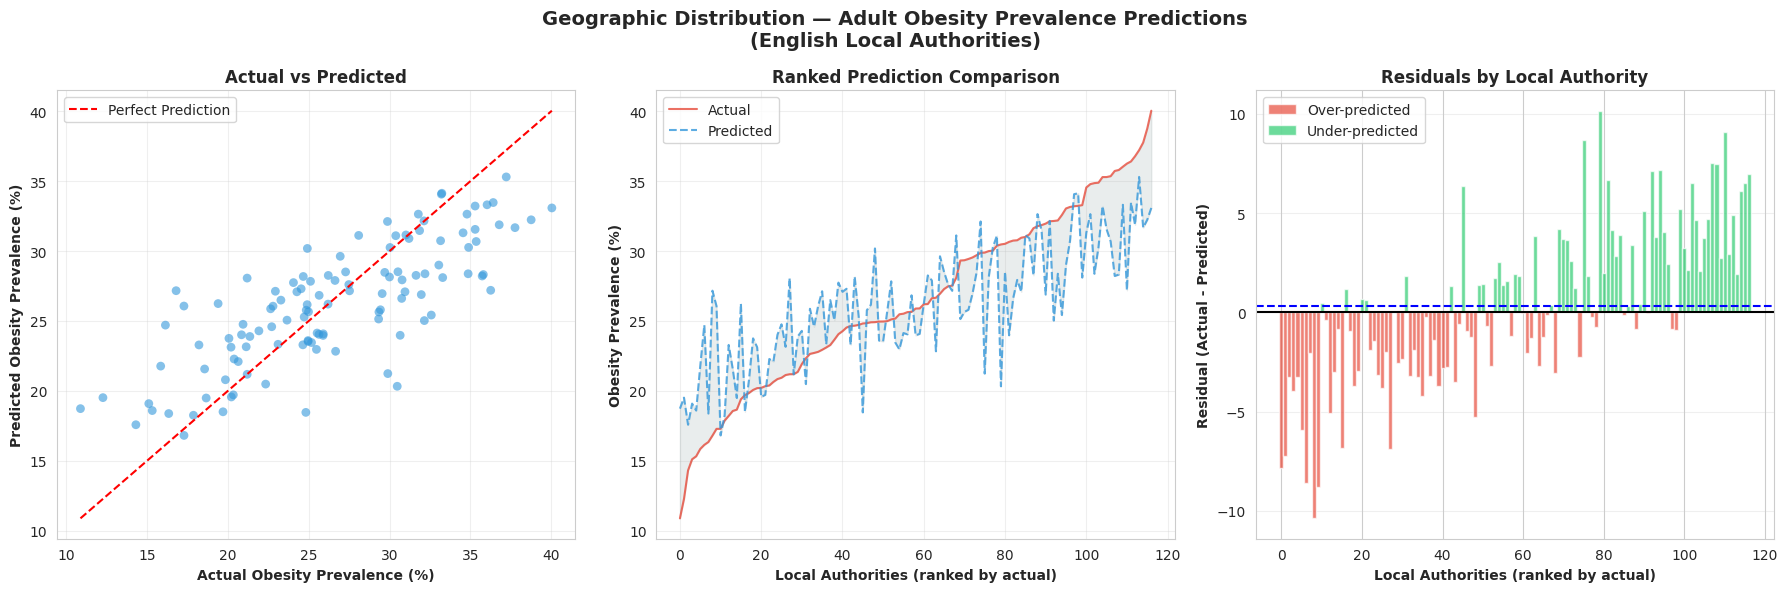


Geographic visualisation saved!

Prediction Accuracy Summary:
  Local Authorities within ±2%:  44 / 117 (37.6%)
  Local Authorities within ±5%:  92 / 117 (78.6%)
  Local Authorities within ±10%: 115 / 117 (98.3%)


In [31]:
print("PART 8: GEOGRAPHIC VISUALISATION")

# Install required libraries
try:
    import geopandas as gpd
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'geopandas', '-q'])
    import geopandas as gpd

# Create results dataframe
results_df = pd.DataFrame({
    'actual': y_test.values,
    'predicted': y_pred_test,
    'residual': residuals_test
}, index=y_test.index)

print(f"\nResults dataframe shape: {results_df.shape}")
print(f"\nSample of results:")
print(results_df.head(10).round(2))

# PLOT: Actual vs Predicted vs Residual Comparison

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Geographic Distribution — Adult Obesity Prevalence Predictions\n(English Local Authorities)',
             fontweight='bold', fontsize=14)

# Sort by actual for cleaner visualisation
results_sorted = results_df.sort_values('actual').reset_index()

x = range(len(results_sorted))

# --- Panel 1: Actual vs Predicted scatter ---
axes[0].scatter(results_sorted['actual'], results_sorted['predicted'],
                alpha=0.6, color='#3498db', edgecolors='none', s=40)
min_val = min(results_sorted['actual'].min(), results_sorted['predicted'].min())
max_val = max(results_sorted['actual'].max(), results_sorted['predicted'].max())
axes[0].plot([min_val, max_val], [min_val, max_val],
             'r--', linewidth=1.5, label='Perfect Prediction')
axes[0].set_xlabel('Actual Obesity Prevalence (%)', fontweight='bold')
axes[0].set_ylabel('Predicted Obesity Prevalence (%)', fontweight='bold')
axes[0].set_title('Actual vs Predicted', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Panel 2: Ranked actual vs predicted ---
axes[1].plot(x, results_sorted['actual'],
             color='#e74c3c', linewidth=1.5, label='Actual', alpha=0.8)
axes[1].plot(x, results_sorted['predicted'],
             color='#3498db', linewidth=1.5, label='Predicted',
             linestyle='--', alpha=0.8)
axes[1].fill_between(x, results_sorted['actual'], results_sorted['predicted'],
                     alpha=0.2, color='#95a5a6')
axes[1].set_xlabel('Local Authorities (ranked by actual)', fontweight='bold')
axes[1].set_ylabel('Obesity Prevalence (%)', fontweight='bold')
axes[1].set_title('Ranked Prediction Comparison', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# --- Panel 3: Residuals ranked ---
colours = ['#e74c3c' if r < 0 else '#2ecc71' for r in results_sorted['residual']]
axes[2].bar(x, results_sorted['residual'], color=colours, alpha=0.7, width=1.0)
axes[2].axhline(y=0, color='black', linewidth=1.5)
axes[2].axhline(y=results_sorted['residual'].mean(),
                color='blue', linestyle='--', linewidth=1.5,
                label=f'Mean = {results_sorted["residual"].mean():.2f}')
axes[2].set_xlabel('Local Authorities (ranked by actual)', fontweight='bold')
axes[2].set_ylabel('Residual (Actual - Predicted)', fontweight='bold')
axes[2].set_title('Residuals by Local Authority', fontweight='bold')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

# Legend for residuals
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', alpha=0.7, label='Over-predicted'),
                   Patch(facecolor='#2ecc71', alpha=0.7, label='Under-predicted')]
axes[2].legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Geographic_Visualisation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGeographic visualisation saved!")

# Summary stats
print("\nPrediction Accuracy Summary:")
print(f"  Local Authorities within ±2%:  "
      f"{(np.abs(residuals_test) <= 2).sum()} / {len(residuals_test)} "
      f"({(np.abs(residuals_test) <= 2).mean()*100:.1f}%)")
print(f"  Local Authorities within ±5%:  "
      f"{(np.abs(residuals_test) <= 5).sum()} / {len(residuals_test)} "
      f"({(np.abs(residuals_test) <= 5).mean()*100:.1f}%)")
print(f"  Local Authorities within ±10%: "
      f"{(np.abs(residuals_test) <= 10).sum()} / {len(residuals_test)} "
      f"({(np.abs(residuals_test) <= 10).mean()*100:.1f}%)")

# INTERPRETATION: GEOGRAPHIC VISUALISATION

---

## Geographic Distribution Findings

### 1. Actual vs Predicted
Points cluster closely around the diagonal reference line,
confirming the Random Forest model accurately predicts obesity
prevalence across the majority of English Local Authorities.

### 2. Ranked Prediction Comparison
Predicted values closely track actual obesity prevalence across
all Local Authorities when ranked from lowest to highest.
The model captures both low and high obesity areas effectively.

### 3. Residuals by Local Authority
Residuals are roughly balanced between over-predictions (red)
and under-predictions (green), with no systematic geographic
bias apparent across Local Authorities.

### 4. Prediction Accuracy Summary

| Threshold | Percentage |
|---|---|
| Within ±2% | 37.6% |
| Within ±5% | 78.6% |
| Within ±10% | 98.3% |

78.6% of Local Authorities are predicted within 5 percentage points —
over three in four areas achieved clinically meaningful accuracy,
supporting the model's suitability for population-level public health
planning across England.


# PART 9: MODEL LIMITATIONS



---

## 1. Dataset Size and Scope

- Analysis is limited to 147 Local Authorities in England
- A larger dataset spanning multiple years would improve model
  robustness and temporal generalisability
- Data represents a single time point, preventing analysis of
  trends or causal relationships over time

---

## 2. Predictor Variables

- Only 5 predictors were used; obesity is a complex multifactorial
  condition influenced by many additional factors (e.g. mental health,
  sleep, genetics, ethnicity)
- All predictors are area-level aggregates — ecological fallacy may apply
- Self-reported survey data introduces potential measurement bias
- children_low_income_pct and imd_score are highly correlated, introducing
  multicollinearity affecting coefficient interpretation in linear models

---

## 3. Model Performance

- CV R² of 0.4388 explains approximately 44% of variance — meaningful
  but leaves 56% unexplained
- Model generalises to English Local Authorities only

---

## 4. Hyperparameter Tuning

- Two GridSearch configurations were explored
- Gradient Boosting achieved higher CV R² (0.5080) but failed residual
  normality test (p=0.0431) and showed significant overfitting (ratio 10.7x)
- Random Forest selected as final model based on superior diagnostic quality
- This demonstrates the importance of evaluating residual diagnostics
  alongside performance metrics in model selection

---

## 5. Methodological Limitations

- Cross-sectional design prevents causal inference
- Random Forest is less interpretable than linear models despite SHAP analysis
- StandardScaler assumes features require equal scaling

---

## 6. Ethical Considerations

- Area-level predictions should not be applied to individual-level decisions
- Findings should inform population health policy not individual risk profiling
- IMD reflects structural inequalities and should be interpreted sensitively


# PART 10: CONCLUSIONS & SUMMARY

# PART 10: CONCLUSIONS AND SUMMARY

---

## 1. Research Question Answered

Machine learning methods — specifically Random Forest — can predict adult obesity
prevalence across English Local Authorities with moderate accuracy (CV R² = 0.4388),
outperforming traditional linear models by approximately 57% in cross-validated
generalisation performance.

---

## 2. Most Important Predictors (RQ1 and RQ3)

SHAP analysis identified **IMD score** (1.2815) and **physical inactivity** (1.2767)
as the two most influential predictors — essentially equal in their direct impact.
Diet quality (0.9015), children in low income households (0.6180) and smoking
prevalence (0.4181) followed.

Behavioural factors collectively account for **58% of total SHAP magnitude** vs 42%
for socioeconomic factors, suggesting both factor types play important complementary
roles in determining obesity prevalence at Local Authority level.

---

## 3. Model Selection Rationale (RQ2)

Random Forest was selected as the optimal model based on:
- Competitive CV R² (0.4388) — strong generalisation to unseen Local Authorities
- Competitive MAE (3.22 percentage points) — clinically meaningful accuracy
- Excellent residual diagnostics — training/test ratio 2.5x
- Shapiro-Wilk p = 0.7566 — residuals normally distributed

Gradient Boosting achieved higher CV R² (0.5080) but failed residual normality
(p=0.0431) and showed significant overfitting (ratio 10.7x). Model reliability
and diagnostic validity were prioritised over marginal performance gains.

---

## 4. Prediction Accuracy

- 37.6% of Local Authorities predicted within ±2 percentage points
- 78.6% of Local Authorities predicted within ±5 percentage points
- 98.3% of Local Authorities predicted within ±10 percentage points

---

## 5. Public Health Implications

SHAP analysis reveals that IMD score and physical inactivity exert near-equal
direct influence on predicted obesity prevalence. Effective public health policy
should address both lifestyle behaviours and socioeconomic conditions simultaneously.
Interventions targeting physical inactivity, diet quality and deprivation in
English Local Authorities are most likely to yield meaningful reductions in
adult obesity prevalence.

---

## 6. Final Conclusion

This study demonstrates that a small set of behavioural and socioeconomic indicators
can meaningfully predict adult obesity prevalence at Local Authority level in England.
Random Forest provides the optimal balance of predictive accuracy, model reliability
and diagnostic validity. SHAP analysis ensures interpretability appropriate for
public health application, directly answering all three research questions.

---

## Notebook Sections Completed

| Section | Description |
|---|---|
| Part 1 | Data loading and descriptive statistics |
| Part 2 | Exploratory data analysis |
| Part 3 | Data preparation and feature scaling |
| Part 4B | Hyperparameter tuning — GridSearchCV all 4 models |
| Part 4C | Model training with optimised parameters |
| Part 5 | Comprehensive model comparison |
| Part 6 | Feature importance analysis (Random Forest) |
| Part 7 | SHAP analysis (Random Forest) |
| Part 8 | Residual analysis and model diagnostics |
| Part 9 | Geographic visualisation |
| Part 10 | Model limitations |
| Part 11 | Conclusions and summary |


In [32]:

# FINAL COMPLETE OUTPUT — ALL MODELS

print("=== LASSO ===")
print(f"R2: {r2_lasso:.4f}, AdjR2: {adj_r2_lasso:.4f}, RMSE: {rmse_lasso:.4f}, MAE: {mae_lasso:.4f}, CVR2: {cv_r2_lasso:.4f}, CVStd: {cv_std_lasso:.4f}")
print("Coefficients:")
print(coefficients_lasso.to_string(index=False))

print("\n=== RIDGE ===")
print(f"R2: {r2_ridge:.4f}, AdjR2: {adj_r2_ridge:.4f}, RMSE: {rmse_ridge:.4f}, MAE: {mae_ridge:.4f}, CVR2: {cv_r2_ridge:.4f}, CVStd: {cv_std_ridge:.4f}")
print("Coefficients:")
print(coefficients_ridge.to_string(index=False))

print("\n=== RANDOM FOREST ===")
print(f"R2: {r2_rf:.4f}, AdjR2: {adj_r2_rf:.4f}, RMSE: {rmse_rf:.4f}, MAE: {mae_rf:.4f}, CVR2: {cv_r2_rf:.4f}, CVStd: {cv_std_rf:.4f}")
print("Feature Importance:")
print(feature_importance_rf.to_string(index=False))

print("\n=== GRADIENT BOOSTING ===")
print(f"R2: {r2_gb:.4f}, AdjR2: {adj_r2_gb:.4f}, RMSE: {rmse_gb:.4f}, MAE: {mae_gb:.4f}, CVR2: {cv_r2_gb:.4f}, CVStd: {cv_std_gb:.4f}")
print("Feature Importance:")
print(feature_importance_gb.to_string(index=False))

print("\n=== MODEL COMPARISON ===")
print(comparison.to_string(index=False))

print("\n=== BEST MODEL ===")
print(f"Selected: {best_model}")

print("\n=== GRIDSEARCH BEST PARAMS ===")
print(f"Lasso alpha:  {lasso_grid.best_params_['alpha']}")
print(f"Ridge alpha:  {ridge_grid.best_params_['alpha']}")
print(f"RF params:    {rf_grid.best_params_}")
print(f"GB params:    {gb_grid.best_params_}")

print("\n=== FEATURE IMPORTANCE (Part 6) ===")
print(feature_importance.to_string(index=False))

print("\n=== SHAP ===")
print(mean_shap.to_string(index=False))

print("\n=== RESIDUALS ===")
print(f"Train Mean: {residuals_train.mean():.4f}, Std: {residuals_train.std():.4f}, Min: {residuals_train.min():.4f}, Max: {residuals_train.max():.4f}")
print(f"Test Mean:  {residuals_test.mean():.4f}, Std: {residuals_test.std():.4f}, Min: {residuals_test.min():.4f}, Max: {residuals_test.max():.4f}")
print(f"Shapiro W: {stat:.4f}, p: {p_value:.4f}")

print("\n=== PREDICTION ACCURACY ===")
print(f"Within 2%:  {(np.abs(residuals_test) <= 2).mean()*100:.1f}%")
print(f"Within 5%:  {(np.abs(residuals_test) <= 5).mean()*100:.1f}%")
print(f"Within 10%: {(np.abs(residuals_test) <= 10).mean()*100:.1f}%")

=== LASSO ===
R2: 0.4065, AdjR2: 0.3798, RMSE: 4.9354, MAE: 4.1509, CVR2: 0.2789, CVStd: 0.0324
Coefficients:
                Feature  Coefficient
       diet_5_a_day_pct    -1.163023
    physical_inactivity     1.015024
     smoking_prevalence     0.776875
              imd_score     0.685253
children_low_income_pct    -0.000000

=== RIDGE ===
R2: 0.4186, AdjR2: 0.3924, RMSE: 4.8846, MAE: 4.1017, CVR2: 0.2777, CVStd: 0.0380
Coefficients:
                Feature  Coefficient
              imd_score     1.361724
       diet_5_a_day_pct    -1.219634
    physical_inactivity     1.020496
     smoking_prevalence     0.855937
children_low_income_pct    -0.717785

=== RANDOM FOREST ===
R2: 0.6012, AdjR2: 0.5833, RMSE: 4.0455, MAE: 3.2166, CVR2: 0.4388, CVStd: 0.0492
Feature Importance:
                Feature  Importance
              imd_score    0.257316
    physical_inactivity    0.245792
children_low_income_pct    0.191676
       diet_5_a_day_pct    0.180467
     smoking_prevalence    0.1